# Setting

## Import packages

In [2]:
# === System & Utility ===
import ast
from math import radians, cos, sin, asin, sqrt
import os
import glob
import re
import time
import json
import math
import itertools
import datetime
from dotenv import load_dotenv
import requests
from urllib.parse import quote
import populartimes

# === Data Handling ===
import pandas as pd
import numpy as np
import geopandas as gpd

# === Geospatial & Location ===
import osmnx as ox
from shapely.geometry import Point
from shapely.wkt import dumps, loads
from geopy.geocoders import Nominatim

# === Visualization ===
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

# === Statistical Tools ===
from scipy import stats
from scipy.stats import norm, chi2_contingency, pointbiserialr

# === Preprocessing & Dimensionality Reduction ===
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

# === Evaluation Metrics ===
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, make_scorer, roc_auc_score
)

# === Classification Models ===
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

# === Regression Models ===
from sklearn.linear_model import LinearRegression, Ridge, Lasso, SGDRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

# === Display Settings ===
pd.set_option('display.precision', 4)

## Self-defined functions

### Common

#### check_table_info

In [3]:
def check_table_info(target_df):
    """
    To check the unique values, dtype, example, missing rate of each column
    """
    table_info = []
    for col in target_df:
        table_info_row = []
        table_info_row.append(col)
        table_info_row.append(target_df[col].nunique())
        table_info_row.append(target_df[col].dtype)
        table_info_row.append(target_df[col].iloc[0])
        table_info_row.append(round(target_df[col].isna().sum() / target_df.shape[0]*100,2))

        table_info.append(table_info_row)
    res = pd.DataFrame(table_info, columns=['col_name', 'unique_values', 'dtype', 'example', 'missing%'])

    return res

#### load_geoDataFrame

In [4]:
def load_geoDataFrame(filepath):
    """
    Load a GeoDataFrame from a CSV file with a geometry column in WKT format.

    Parameters:
        filepath (str): Path to the CSV file containing the saved GeoDataFrame.

    Returns:
        GeoDataFrame: A GeoDataFrame reconstructed from the CSV, with geometries parsed from WKT strings.
    
    Notes:
        - Assumes the geometry column is named 'geometry' and stored in WKT format.
        - The returned GeoDataFrame is assigned the CRS 'EPSG:4326' by default.
    """
    df = pd.read_csv(filepath)
    df['geometry'] = df['geometry'].apply(loads)
    return gpd.GeoDataFrame(df, geometry='geometry', crs="EPSG:4326")

#### gen_point_area_mapping

In [5]:
def gen_point_area_mapping(point_df, lat_col, lon_col, geometry_df, geometry_col='geometry'):
    """
    Maps each point in point_df to a polygon in geometry_df using spatial join.

    Parameters:
        point_df (pd.DataFrame): DataFrame with latitude and longitude columns.
        lat_col (str): Column name for latitude.
        lon_col (str): Column name for longitude.
        geometry_df (gpd.GeoDataFrame): GeoDataFrame containing polygon geometries.
        geometry_col (str): Column name for the geometry column in geometry_df.

    Returns:
        gpd.GeoDataFrame: Result of spatial join with matching polygons.
    """
    # Drop rows with missing coordinates
    point_df = point_df.dropna(subset=[lat_col, lon_col]).copy()

    # Convert to GeoDataFrame
    point_gdf = gpd.GeoDataFrame(
        point_df,
        geometry=gpd.points_from_xy(point_df[lon_col], point_df[lat_col]),
        crs="EPSG:4326"
    )

    # Ensure geometry_df is a GeoDataFrame with proper CRS
    area_gdf = geometry_df.copy()
    if geometry_col != 'geometry':
        area_gdf = area_gdf.set_geometry(geometry_col)
    if area_gdf.crs != "EPSG:4326":
        area_gdf = area_gdf.to_crs("EPSG:4326")

    # Perform spatial join
    joined = gpd.sjoin(point_gdf, area_gdf, how='inner', predicate='within')

    return joined

#### gen_distance_to_case

In [6]:
def gen_distance_to_case(restaurant_df, case_google_name):
    case_lat = restaurant_df[restaurant_df['google_name'] == case_google_name]['lat'].iloc[0]
    case_lon = restaurant_df[restaurant_df['google_name'] == case_google_name]['lon'].iloc[0]
    col_name = 'distance_to_' + case_google_name.lower().replace(' ', '_')
    display(col_name)
    restaurant_df[col_name] = restaurant_df.apply(
        lambda row: haversine(case_lat, case_lon, row['lat'], row['lon']),
        axis=1
    )
    return restaurant_df

In [7]:

def haversine(lat1, lon1, lat2, lon2):
    """
    Calculate the great-circle distance between two points (in km)
    """
    R = 6371  # Earth radius in km
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1 
    dlon = lon2 - lon1 
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    return R * 2 * asin(sqrt(a))

#### save_restaurant_info_progress_csv

In [8]:
def save_restaurant_info_progress_csv(df):
    target_columns = ['full_name', 'place_id', 'google_name', 'address', 
                  'phone', 'lat', 'lon', 
                  'cuisine_keyword', 'image_url', 'grid_id', 
                  'rating', 'review_count', 'price_level', 
                  'opening_hour', 'wheelchair_friendly',
                  'inspection_date', 'inspection_grade', 'cuisine_type', 'amenities']

    df[target_columns].to_csv('../prepared_outputs/restaurant_info.csv', index=False)
    df.to_csv('restaurant_info_wip.csv', index=False)

### Match yelp-data

#### normalize_name

In [9]:
def normalize_name(name):
    if pd.isna(name):
        return ""
    return re.sub(r'[\W_]+', '', name).lower()

#### clean_us_phone_safe

In [10]:
def clean_us_phone_safe(phone):
    # If input is a float, convert it to a plain integer string without decimals
    try:
        if isinstance(phone, float):
            phone = '{:.0f}'.format(phone)   # Prevent decimal formatting
    except:
        pass
    digits = re.sub(r'\D', '', str(phone))
    
    if len(digits) == 11 and digits.startswith('1'):
        return digits[1:]
    if len(digits) == 10:
        return digits
    return None

#### parse_business_hours

In [11]:
def parse_business_hours(row, business_hours_col='business_hours', name_col='full_name'):
    try:
        # Safely convert string to Python object
        opening_data = ast.literal_eval(row[business_hours_col])
        if not opening_data:
            return None

        open_entries = opening_data[0].get('open', [])
    except Exception:
        return None

    # Initialize the result list
    result = []
    for day in range(7):
        day_row = {'day': day}
        for hour in range(24):
            day_row[f'hour_{hour}'] = 0
        result.append(day_row)

    for entry in open_entries:
        start = int(entry['start'][:2])
        end = int(entry['end'][:2])
        day = entry['day']
        is_overnight = entry['is_overnight']

        if not is_overnight:
            for hour in range(start, end):
                result[day][f'hour_{hour % 24}'] = 1
        else:
            for hour in range(start, 24):
                result[day][f'hour_{hour}'] = 1
            for hour in range(0, end):
                result[(day + 1) % 7][f'hour_{hour}'] = 1

    result_df = pd.DataFrame(result)
    result_df.insert(0, name_col, row[name_col])
    return result_df

### Google Place Data

#### add_google_data

In [57]:
import requests
import pandas as pd
import datetime
import re

def convert_to_24h(time_str, assume_pm=False):
    time_str = re.sub(r'[\u202f\u2009]', '', time_str.strip())
    if 'AM' in time_str.upper() or 'PM' in time_str.upper():
        t = datetime.datetime.strptime(time_str.upper(), "%I:%M%p")
    else:
        # 沒 AM/PM，用 24 小時，或假設為 PM
        t = datetime.datetime.strptime(time_str, "%H:%M")
        if assume_pm and t.hour < 12:
            t = t.replace(hour=t.hour + 12)
    return t.strftime("%H:%M")


def parse_opening_hours(opening_hours_list):
    result = {}
    for entry in opening_hours_list:
        if ": " not in entry:
            continue
        day, hours = entry.split(": ", 1)
        if 'Closed' in hours:
            result[day] = []
            continue
        
        periods = hours.split(",")
        periods_24h = []

        for period in periods:
            if '–' not in period:
                continue
            open_time, close_time = period.strip().split('–')
            open_time = open_time.strip()
            close_time = close_time.strip()
            is_pm = 'PM' in close_time.upper()

            open_24h = convert_to_24h(open_time, assume_pm=is_pm)
            close_24h = convert_to_24h(close_time)

            periods_24h.append(f"{open_24h} - {close_24h}")
        result[day] = periods_24h
    return result

def add_google_data(df, target_df, google_api_key, ref_col):
    for i, row in target_df.iterrows():
        if pd.notna(row[ref_col]):
            print(f"{row['full_name']} {ref_col} exists: {row[ref_col]}")
            continue

        fields = (
            'name,opening_hours,rating,user_ratings_total,price_level,'
            'delivery,dine_in,reservable,wheelchair_accessible_entrance,'
            'serves_beer,serves_breakfast,serves_brunch,serves_dinner,'
            'serves_lunch,serves_vegetarian_food,serves_wine,takeout'
        )
        url = (
            f'https://maps.googleapis.com/maps/api/place/details/json'
            f'?place_id={row["place_id"]}'
            f'&fields={fields}'
            f'&key={google_api_key}'
        )

        response = requests.get(url)
        data = response.json()
        if data.get('status') != 'OK':
            continue

        result = data['result']

        # Update opening hour
        if 'opening_hours' in result:
            opening_hour = parse_opening_hours(result['opening_hours']['weekday_text'])
            df.at[i, 'opening_hour'] = opening_hour

        # Update amenities
        amenities_fields = [
            'delivery', 'dine_in', 'reservable', 'wheelchair_accessible_entrance',
            'serves_beer', 'serves_breakfast', 'serves_brunch', 'serves_dinner',
            'serves_lunch', 'serves_vegetarian_food', 'serves_wine', 'takeout'
        ]
        amenities = [field for field in amenities_fields if result.get(field) is True]
        if amenities:
            df.at[i, 'amenities'] = amenities

        # Update other fields
        if 'name' in result:
            df.at[i, 'google_name'] = result.get('name')

        if 'user_ratings_total' in result:
            df.at[i, 'review_count'] = result['user_ratings_total']

        if 'wheelchair_accessible_entrance' in result:
            df.at[i, 'wheelchair_friendly'] = int(bool(result['wheelchair_accessible_entrance']))

        if 'price_level' in result:
            df.at[i, 'price_level'] = '$' * int(result['price_level'])

        if 'rating' in result:
            df.at[i, 'rating'] = result['rating']

        print(f"{i}: {row['full_name']} updated.")

    return df

#### fill_place_id

In [13]:
def fill_place_id(df, target_df, google_api_key):
    for i, row in target_df.iterrows():
        if pd.notna(row['place_id']):
            print(f"{row['full_name']} place_id exists: {row['place_id']}")
            continue
        place_name = row['full_name'] + ', Manhattan, New York'
        place_id = fetch_google_place_id(api_key=google_api_key,
                                         place_name=place_name)
        df.at[i, 'place_id'] = place_id
        print(i, row['full_name'], place_id)
    return df

#### fetch_google_place_id

In [14]:
def fetch_google_place_id(api_key, place_name):
    search_url = "https://maps.googleapis.com/maps/api/place/findplacefromtext/json"
    search_params = {
        "input": place_name,
        "inputtype": "textquery",
        "fields": "place_id",
        "key": api_key
    }
    
    try:
        response = requests.get(search_url, params=search_params, timeout=5)
        response.raise_for_status()
        sres = response.json()
        
        candidates = sres.get("candidates", [])
        if not candidates:
            return False  # No result found
        return candidates[0].get("place_id")
    
    except Exception as e:
        return False  # Error occurred

#### gen_place_info_popularity_df

In [15]:
def gen_place_info_popularity_df(response):
    """
    Converts a populartimes.get_id() response into two DataFrames:
    
    - place_info_df: Basic info about the place (ID, name, rating, location, etc.)
    - popularity_df: Hourly popularity data per weekday (hour_0 to hour_23)
    
    Parameters:
        response (dict): Result from populartimes.get_id()
    
    Returns:
        tuple: (place_info_df, popularity_df)
    """
    place_info_df = pd.DataFrame([{
        'place_id': response.get('id', ''),
        'name': response.get('name', ''),
        'address': response.get('address', ''),
        'types': ','.join(response.get('types', [])),
        'lat': response.get('coordinates', {}).get('lat', 0),
        'lon': response.get('coordinates', {}).get('lng', 0),
        'rating': response.get('rating', 0),
        'review_count': response.get('rating_n', 0),
        'phone': response.get('international_phone_number', ''),
        'time_spent_min': response.get('time_spent', [0, 0])[0],
        'time_spent_max': response.get('time_spent', [0, 0])[1]
    }])
    
    popularity_rows = []
    for day_data in response.get('populartimes', []):
        row = {'place_id': response['id'], 'day': day_data['name']}
        row.update({f'hour_{hour}': value for hour, value in enumerate(day_data['data'])})
        popularity_rows.append(row)

    popularity_df = pd.DataFrame(popularity_rows)
    
    return place_info_df, popularity_df

#### parse_opening_hours

In [16]:
def parse_opening_hours(row, opening_hours_col='opening_hours', name_col='full_name'):

    days_map = {
        "Monday": 0, "Tuesday": 1, "Wednesday": 2,
        "Thursday": 3, "Friday": 4, "Saturday": 5, "Sunday": 6
    }

    result = []
    for day in range(7):
        day_row = {"day": day}
        for h in range(24):
            day_row[f"hour_{h}"] = 0
        result.append(day_row)

    closed_days = set()
    opening_str = row.get(opening_hours_col, "")
    entries = [e.strip() for e in opening_str.split(";") if e.strip()]

    for entry in entries:
        match = re.match(r"(\w+):\s*(.*)", entry)
        if not match:
            continue
        day_str, times = match.groups()
        day = days_map.get(day_str)
        if day is None:
            continue

        if "closed" in times.lower():
            closed_days.add(day)
            continue

        if "open 24 hours" in times.lower():
            for h in range(24):
                result[day][f"hour_{h}"] = 1
            continue

        time_ranges = [r.strip() for r in times.split(",")]
        for time_range in time_ranges:
            try:
                time_range = time_range.replace("\u202f", "").replace("\u2009", "").replace("\u00a0", "").lower()

                if "–" not in time_range:
                    raise ValueError("No dash found in time range")

                start_str, end_str = [s.strip() for s in time_range.split("–")]

                # 補 AM/PM：如果 start 沒有標示，但 end 有，就補給 start
                am_pm_match = re.search(r'(am|pm)', end_str)
                if am_pm_match and not re.search(r'(am|pm)', start_str):
                    start_str += am_pm_match.group()

                start = datetime.datetime.strptime(start_str, "%I:%M%p")
                end = datetime.datetime.strptime(end_str, "%I:%M%p")
                start_hour = start.hour
                end_hour = end.hour
                is_overnight = end <= start

                if not is_overnight:
                    for h in range(start_hour, end_hour):
                        result[day][f"hour_{h}"] = 1
                else:
                    for h in range(start_hour, 24):
                        result[day][f"hour_{h}"] = 1
                    next_day = (day + 1) % 7
                    for h in range(0, end_hour):
                        result[next_day][f"hour_{h}"] = 1

            except Exception as e:
                print(f"⚠️ Failed to parse time range '{time_range}' for {day_str}: {e}")
                continue

    df = pd.DataFrame(result)
    df.insert(0, name_col, row[name_col])
    return df

### Yelp API

#### fetch_yelp_by_name

In [17]:
def fetch_yelp_by_name(api_key, name, latitude=None, longitude=None, limit=5):
    """
    Fetch Yelp restaurant data using a restaurant name.

    Args:
        api_key (str): Your Yelp Fusion API key.
        name (str): Name of the restaurant to search.
        latitude (float, optional): Latitude for location-based refinement.
        longitude (float, optional): Longitude for location-based refinement.
        limit (int): Max number of results to return (default: 5).

    Returns:
        list[dict]: List of matched Yelp business data dictionaries.
    """
    headers = {
        'Authorization': f'Bearer {api_key}',
    }

    params = {
        'term': name,
        'limit': limit,
    }

    if latitude and longitude:
        params['latitude'] = latitude
        params['longitude'] = longitude
    else:
        # Optional: default to NYC or another known location
        params['location'] = 'Manhattan, NY'

    url = 'https://api.yelp.com/v3/businesses/search'

    try:
        response = requests.get(url, headers=headers, params=params)
        if response.status_code == 200:
            data = response.json()
            return data.get('businesses', [])
        else:
            print(f"Error {response.status_code}: {response.text}")
            return []
    except Exception as e:
        print(f"Exception occurred: {e}")
        return []

# Restuarnt info
Integrate data from the Yelp Fusion API, Google Places API, and NYC Inspection Results into a unified DataFrame, and convert both Google opening hours and Yelp business hours into the same hourly format used by the popular times data.

In [15]:
restaurant_source = pd.read_csv('google_api_restaurant_metadata_step2.csv')
restaurant_source = restaurant_source[['full_name', 'place_id', 'name', 'address',
                                       'opening_hours', 'phone',
                                       'rating', 'review_count']]
restaurant_source.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10538 entries, 0 to 10537
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   full_name      10537 non-null  object 
 1   place_id       867 non-null    object 
 2   name           761 non-null    object 
 3   address        761 non-null    object 
 4   opening_hours  174 non-null    object 
 5   phone          713 non-null    object 
 6   rating         759 non-null    float64
 7   review_count   759 non-null    float64
dtypes: float64(2), object(6)
memory usage: 658.8+ KB


In [16]:
restaurant_source['full_name'].value_counts()

full_name
D.J. REYNOLDS 351 WEST   57 STREET               1
LOCO COCO 2907 BROADWAY                          1
NEW LUCK GARDEN 1954 AMSTERDAM AVENUE            1
SIMPLY NOODLES 267 AMSTERDAM AVENUE              1
CATERING KITCHEN (GOOGLE) 29 11 AVENUE           1
                                                ..
BAR (GARDEN BAR 6TH FLOOR) 4 PENN PLAZA          1
THE LAZY LLAMA COFFEE BAR 72 EAST    1 STREET    1
PRESS ROOM 4 PENN PLZ                            1
HOT DOG CONCESSION (FC6100) 4 PENN PLZ           1
ERA - NEW YORK 589 11 AVENUE                     1
Name: count, Length: 10537, dtype: int64

## Inspection data

In [17]:
inspection_df = pd.read_csv('../inspection/Inspection_latest_Results_cleaned_step2.csv')
inspection_df['full_name'] = inspection_df['DBA'] + ' ' + inspection_df['BUILDING'] + ' ' + inspection_df['STREET']
inspection_df['inspection_date'] = pd.to_datetime(inspection_df['INSPECTION DATE'])
inspection_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10609 entries, 0 to 10608
Data columns (total 40 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   Unnamed: 0                      10609 non-null  int64         
 1   CAMIS                           10609 non-null  int64         
 2   DBA                             10609 non-null  object        
 3   BUILDING                        10596 non-null  object        
 4   STREET                          10609 non-null  object        
 5   ZIPCODE                         10439 non-null  float64       
 6   PHONE                           10607 non-null  object        
 7   CUISINE DESCRIPTION             10609 non-null  object        
 8   INSPECTION DATE                 10609 non-null  object        
 9   ACTION                          10609 non-null  object        
 10  VIOLATION CODE                  10280 non-null  object        
 11  VI

In [18]:
insepection_last_date = inspection_df.groupby(['full_name'])['inspection_date'].max().reset_index(name='inspection_date')

inspection_info = insepection_last_date.merge(inspection_df[['full_name', 'inspection_date', 'PHONE', 'GRADE', 'CUISINE DESCRIPTION',
                                                             'Latitude', 'Longitude',
                                                            ]], on=['full_name', 'inspection_date'])
inspection_info = inspection_info.drop_duplicates(subset='full_name', keep='last')
inspection_info

,full_name,inspection_date,PHONE,GRADE,CUISINE DESCRIPTION,Latitude,Longitude
0,"""U"" LIKE CHINESE TAKE OUT 4926 BROADWAY",2025-05-20,2129426668,NaN,Chinese,40.8675,-73.9217
1,"""W"" CAFE 390 5TH AVE",2024-04-10,2125639444,A,American,40.7498,-73.9841
2,$1 PIZZA 333B AVENUE OF THE AMERICAS,2025-05-13,5513581106,NaN,Pizza,40.7314,-74.0012
3,$1 PIZZA 832 6 AVENUE,2024-10-03,9175878888,A,Pizza,40.7465,-73.9902
4,$1.50 FRESH PIZZA & HOT DOG 131 AVENUE A,2025-02-13,6464093489,B,Pizza,40.7268,-73.9830
...,...,...,...,...,...,...,...
10555,abcV 96 SOUTH STREET,2024-04-03,5167136011,A,Vegan,40.7064,-74.0029
10556,i-TASTE EXPRESS 52 WEST 28 STREET,2025-04-02,2123478383,A,Chinese,40.7456,-73.9895
10557,iPizza NY 351 WEST 125 STREET,2025-03-04,9172658973,A,Pizza,40.8109,-73.9528
10558,iPizzaNY 658 9 AVENUE,2025-03-04,9176757587,NaN,Pizza,40.7608,-73.9909


## Yelp data

In [20]:
yelp_df = pd.read_csv("yelp_manhattan_step2_18731.csv")
yelp_df['normalized_name'] = yelp_df['name'].apply(normalize_name)
yelp_df['normalized_phone'] = yelp_df['phone'].apply(clean_us_phone_safe)

selected_yelp_cols = ['normalized_name', 'coordinates.latitude', 'coordinates.longitude',
                      'normalized_phone', 
                      'review_count', 'categories', 'rating', 'image_url', 'business_hours', 'price']
yelp_df[selected_yelp_cols].head()

,normalized_name,coordinates.latitude,coordinates.longitude,normalized_phone,review_count,categories,rating,image_url,business_hours,price
0,theviewatthebattery,40.7016,-74.0149,2128095508,53,"[{'alias': 'newamerican', 'title': 'New Americ...",3.7,https://s3-media3.fl.yelpcdn.com/bphoto/Facy_G...,"[{'open': [{'is_overnight': False, 'start': '1...",$$
1,subway,40.7016,-74.0138,2129431800,1,"[{'alias': 'sandwiches', 'title': 'Sandwiches'...",1.0,https://s3-media2.fl.yelpcdn.com/bphoto/xOUUZb...,"[{'open': [{'is_overnight': False, 'start': '0...",NaN
2,wendys,40.7010,-74.0130,2122209989,34,"[{'alias': 'burgers', 'title': 'Burgers'}, {'a...",2.0,https://s3-media4.fl.yelpcdn.com/bphoto/3Celnf...,"[{'open': [{'is_overnight': False, 'start': '1...",$
3,centralmarketnewyork,40.7010,-74.0130,2125145220,10,"[{'alias': 'burgers', 'title': 'Burgers'}, {'a...",2.7,https://s3-media3.fl.yelpcdn.com/bphoto/_xoJsM...,"[{'open': [{'is_overnight': True, 'start': '00...",$$$$
4,auntieannes,40.7010,-74.0130,6315747700,0,"[{'alias': 'pretzels', 'title': 'Pretzels'}, {...",0.0,https://s3-media2.fl.yelpcdn.com/bphoto/O8VFKS...,"[{'open': [{'is_overnight': False, 'start': '1...",NaN


In [21]:
# Only select 'yelp_combined_match_confidence' = High records
matched_in_yelp = inspection_df[['full_name', 'normalized_name', 'in_yelp_by_name_or_phone', 'in_yelp_by_name', 'yelp_lat', 'yelp_lon', 'in_yelp_by_phone', 'normalized_phone', 'yelp_combined_match_confidence']]
matched_in_yelp = matched_in_yelp[matched_in_yelp['in_yelp_by_name_or_phone'] == True]
matched_in_yelp.loc[:, 'normalized_phone'] = matched_in_yelp['normalized_phone'].astype('Int64').astype('str')
matched_in_yelp = matched_in_yelp[matched_in_yelp['yelp_combined_match_confidence'] == 'high']

# Get yelp info for data with matched name
matched_in_yelp_name = matched_in_yelp[matched_in_yelp['in_yelp_by_name'] == True]
display(matched_in_yelp_name.shape)
name_matched = matched_in_yelp_name.merge(yelp_df[selected_yelp_cols], left_on=['normalized_name', 'yelp_lat', 'yelp_lon'], right_on=['normalized_name', 'coordinates.latitude', 'coordinates.longitude'])
display(name_matched.shape)

# Get yelp info for data with matched phone
matahced_in_yelp_phone = matched_in_yelp[matched_in_yelp['in_yelp_by_phone'] == True]
display(matahced_in_yelp_phone.shape)
phone_matched = matahced_in_yelp_phone.merge(yelp_df[selected_yelp_cols], left_on=['normalized_phone', 'yelp_lat', 'yelp_lon'], right_on=['normalized_phone', 'coordinates.latitude', 'coordinates.longitude'])
display(phone_matched.shape)

/var/folders/l_/zlzp_vvs4j31hx3pg4j26tch0000gn/T/ipykernel_31123/1242681011.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['2122452912' '2129323030' '2129952570' ... '6464100700' '2123439426'
 '9178562699']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  matched_in_yelp.loc[:, 'normalized_phone'] = matched_in_yelp['normalized_phone'].astype('Int64').astype('str')


(3733, 9)

(3432, 18)

(4024, 9)

(3982, 18)

In [22]:
yelp_df[yelp_df['normalized_name'] == 'casabella'][selected_yelp_cols]

,normalized_name,coordinates.latitude,coordinates.longitude,normalized_phone,review_count,categories,rating,image_url,business_hours,price
16975,casabella,40.8288,-73.9492,2122815124,1,"[{'alias': 'tradamerican', 'title': 'American'}]",3.0,NaN,[],NaN


In [23]:
matched_in_yelp_name[matched_in_yelp_name['normalized_name'] == 'casabella']

,full_name,normalized_name,in_yelp_by_name_or_phone,in_yelp_by_name,yelp_lat,yelp_lon,in_yelp_by_phone,normalized_phone,yelp_combined_match_confidence
91,CASA BELLA 127 MULBERRY STREET,casabella,True,True,40.7181,-73.9982,True,2124314080,high


In [35]:
target_cols = ['full_name', 'review_count', 'categories', 'rating', 'image_url', 'business_hours', 'price']
yelp_matched_data = pd.concat([phone_matched[target_cols], name_matched[target_cols]])
yelp_matched_data = yelp_matched_data.drop_duplicates(subset='full_name', keep='last')
yelp_matched_data.to_csv('yelp_matched_data.csv')
yelp_matched_data

,full_name,review_count,categories,rating,image_url,business_hours,price
1,P & S DELI GROCERY 730 COLUMBUS AVENUE,3,"[{'alias': 'delis', 'title': 'Delis'}]",1.0,NaN,[],NaN
2,ANGELIKA FILM CENTER 18 WEST HOUSTON STREET,515,"[{'alias': 'movietheaters', 'title': 'Cinema'}...",3.4,https://s3-media3.fl.yelpcdn.com/bphoto/N4j90a...,"[{'open': [{'is_overnight': False, 'start': '1...",$$
3,MISS MAIME'S SPOONBREAD TOO 364 WEST 110 STREET,491,"[{'alias': 'southern', 'title': 'Southern'}, {...",3.3,https://s3-media2.fl.yelpcdn.com/bphoto/6FYjzJ...,"[{'open': [{'is_overnight': False, 'start': '1...",$$
4,ISLE OF CAPRI RESTURANT 1028 3 AVENUE,326,"[{'alias': 'italian', 'title': 'Italian'}]",4.1,https://s3-media2.fl.yelpcdn.com/bphoto/IVhVHl...,"[{'open': [{'is_overnight': False, 'start': '1...",$$$
6,SEVILLA RESTAURANT 62 CHARLES STREET,595,"[{'alias': 'spanish', 'title': 'Spanish'}, {'a...",3.7,https://s3-media2.fl.yelpcdn.com/bphoto/gOEXxr...,"[{'open': [{'is_overnight': False, 'start': '1...",$$
...,...,...,...,...,...,...,...
3427,RELIABLE FOOD 59 EAST 54 STREET,31,"[{'alias': 'delis', 'title': 'Delis'}]",3.4,https://s3-media3.fl.yelpcdn.com/bphoto/ozNmjy...,"[{'open': [{'is_overnight': False, 'start': '0...",$$
3428,7 SPRING 7 SPRING STREET,0,"[{'alias': 'tabletopgames', 'title': 'Tabletop...",0.0,NaN,[],NaN
3429,DEUX LUXE 384 BROOME STREET,4,"[{'alias': 'burgers', 'title': 'Burgers'}]",4.8,https://s3-media3.fl.yelpcdn.com/bphoto/T-9bEp...,[],NaN
3430,LADY CHOW KITCHEN 171 HESTER STREET,81,"[{'alias': 'dimsum', 'title': 'Dim Sum'}, {'al...",3.9,https://s3-media1.fl.yelpcdn.com/bphoto/gEayx6...,"[{'open': [{'is_overnight': False, 'start': '0...",NaN


## Integrate datasets

In [25]:
restaurant_merged = restaurant_source.merge(inspection_info, on='full_name')
restaurant_merged = restaurant_merged.merge(yelp_matched_data, on='full_name', how='left', suffixes=('','_yelp'))
restaurant_merged = restaurant_merged.rename(columns={'name': 'google_name',
                                                  'PHONE': 'phone',
                                                  'GRADE': 'inspection_grade',
                                                  'CUISINE DESCRIPTION': 'cuisine_type',
                                                  'Latitude': 'lat',
                                                  'Longitude': 'lon',
                                                  'categories': 'cuisine_keyword',
                                                  'price': 'price_level'
                                                 }
                                        )
restaurant_merged.head()

,full_name,place_id,google_name,address,opening_hours,phone,rating,review_count,inspection_date,phone,inspection_grade,cuisine_type,lat,lon,review_count_yelp,cuisine_keyword,rating_yelp,image_url,business_hours,price_level
0,D.J. REYNOLDS 351 WEST 57 STREET,ChIJ03By9lhYwokRfGgIPEcxNlM,D.J. Reynolds,"351 W 57th St, New York, NY 10019, USA",Monday: 2:30 PM – 4:00 AM; Tuesday: 2:30 PM – ...,(212) 245-2912,4.3,540.0,2025-02-20,2122452912,A,Irish,40.7673,-73.9843,138.0,"[{'alias': 'irish', 'title': 'Irish'}, {'alias...",3.5,https://s3-media3.fl.yelpcdn.com/bphoto/pQdi2I...,"[{'open': [{'is_overnight': True, 'start': '14...",$$
1,1 EAST 66TH STREET KITCHEN 1 EAST 66 STREET,ChIJYdHIa-lYwokRmeZUvOoldMo,165 East 66 by Stonehenge,"165 E 66th St, New York, NY 10065, USA",Monday: 9:00 AM – 5:00 PM; Tuesday: 9:00 AM – ...,NaN,5.0,2.0,2022-05-03,2128793900,A,American,40.7685,-73.9696,NaN,NaN,NaN,NaN,NaN,NaN
2,P & S DELI GROCERY 730 COLUMBUS AVENUE,ChIJ10yifCf2wokRDiZPK-60xM8,Paul Saini Deli Grocery,"724 Columbus Ave, New York, NY 10025, USA",Monday: 6:00 AM – 11:00 PM; Tuesday: 6:00 AM –...,(212) 932-3030,4.1,82.0,2025-03-27,2129323030,A,American,40.7926,-73.9677,3.0,"[{'alias': 'delis', 'title': 'Delis'}]",1.0,NaN,[],NaN
3,ANGELIKA FILM CENTER 18 WEST HOUSTON STREET,ChIJQ1RTt49ZwokRgYgqG6DdK2w,Angelika Film Center & Cafe - New York,"18 W Houston St, New York, NY 10012, USA",NaN,(212) 995-2570,4.4,2058.0,2023-06-21,2129952570,A,American,40.7257,-73.9975,515.0,"[{'alias': 'movietheaters', 'title': 'Cinema'}...",3.4,https://s3-media3.fl.yelpcdn.com/bphoto/N4j90a...,"[{'open': [{'is_overnight': False, 'start': '1...",$$
4,CAFE METRO 625 8 AVENUE,ChIJQzxNYepZwokRCYqnc_ftZcc,Cafe Metro,"625 8th Ave, New York, NY 10018, USA",NaN,NaN,2.9,9.0,2025-05-01,2127149342,A,American,40.7562,-73.9906,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
restaurant_merged['rating'] = np.where(restaurant_merged['rating'].notna(), restaurant_merged['rating'], restaurant_merged['rating_yelp'])
restaurant_merged['review_count'] = np.where(restaurant_merged['review_count'].notna(), restaurant_merged['review_count'], restaurant_merged['review_count_yelp'])

restaurant_info = restaurant_merged.drop(columns=['review_count_yelp', 'rating_yelp'])
restaurant_info = restaurant_info[(restaurant_info['lat'] != 0) & (restaurant_info['lon'] != 0)]
restaurant_info['lat_rounded'] = restaurant_info['lat'].round(2)
restaurant_info['lon_rounded'] = restaurant_info['lon'].round(2)
grouped = restaurant_info.groupby(['lat_rounded', 'lon_rounded']).size().reset_index(name='restaurant_counts').sort_values('restaurant_counts', ascending=False)
restaurant_info = restaurant_info.merge(grouped, on=['lat_rounded', 'lon_rounded'])
restaurant_info.sort_values('restaurant_counts', ascending=False)

,full_name,place_id,google_name,address,opening_hours,phone,rating,review_count,inspection_date,phone,...,cuisine_type,lat,lon,cuisine_keyword,image_url,business_hours,price_level,lat_rounded,lon_rounded,restaurant_counts
4103,ITAEWON POCHA 28 WEST 32 STREET,ChIJX3vA5ahZwokRd9ZnszaGXFM,NaN,NaN,NaN,NaN,4.1,351.0,2023-12-05,2127142266,...,Korean,40.7477,-73.9869,"[{'alias': 'gastropubs', 'title': 'Gastropubs'...",https://s3-media3.fl.yelpcdn.com/bphoto/rY3OBd...,"[{'open': [{'is_overnight': True, 'start': '17...",$$,40.75,-73.99,676
5928,La Noxe 315 7 AVENUE,ChIJpy4I5A1ZwokRkeVFxbwI2f8,La Noxe,"315 7th Ave , Entrance, 162 W 28th St at, New ...",NaN,+1 917-261-4883,3.9,267.0,2024-08-27,6465094117,...,American,40.7471,-73.9935,NaN,NaN,NaN,NaN,40.75,-73.99,676
5839,FRAME 552 7 AVENUE,ChIJ_f8PaKtZwokRMn1rxf4_gEk,Frame Gourmet Eatery,"552 Fashion Ave, New York, NY 10018, USA",NaN,+1 212-719-0111,4.1,832.0,2025-03-12,2127190111,...,American,40.7545,-73.9881,"[{'alias': 'korean', 'title': 'Korean'}, {'ali...",https://s3-media2.fl.yelpcdn.com/bphoto/X0XMx_...,"[{'open': [{'is_overnight': False, 'start': '0...",$$,40.75,-73.99,676
2671,OCABANON 245 WEST 29 STREET,ChIJnYSJ169ZwokRiH0bzxxTYWM,OCabanon,"245 W 29th St, New York, NY 10001, USA",NaN,+1 646-669-7879,4.4,747.0,2024-11-04,6466697879,...,French,40.7484,-73.9942,"[{'alias': 'french', 'title': 'French'}, {'ali...",https://s3-media4.fl.yelpcdn.com/bphoto/fa8oiF...,"[{'open': [{'is_overnight': False, 'start': '1...",$$,40.75,-73.99,676
2670,PERGOLA 36 36 WEST 28 STREET,ChIJS-435aVZwokRCKIL4x3naMw,Pergola,"36 W 28th St, New York, NY 10001, USA",NaN,+1 212-679-4842,4.0,2384.0,2024-10-16,2126794842,...,Mediterranean,40.7455,-73.9893,"[{'alias': 'hookah_bars', 'title': 'Hookah Bar...",https://s3-media2.fl.yelpcdn.com/bphoto/qrH9pb...,"[{'open': [{'is_overnight': True, 'start': '16...",$$$,40.75,-73.99,676
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,THE RIVER CLUB 447 EAST 52 STREET,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-04-18,2127510100,...,American,40.7547,-73.9642,NaN,NaN,NaN,NaN,40.75,-73.96,1
6421,THE VIEW 10 BATTERY PLACE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-10-14,3472312722,...,American,40.7049,-74.0157,NaN,NaN,NaN,NaN,40.70,-74.02,1
10031,Tasty Picks 3 1901 1 AVENUE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-04-01,6462484128,...,American,40.7846,-73.9438,NaN,NaN,NaN,NaN,40.78,-73.94,1
9851,HELL'S KITCHEN PICKLEBALL CLUB 660 12 AVENUE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-10-04,2129771372,...,Coffee/Tea,40.7660,-73.9973,NaN,NaN,NaN,NaN,40.77,-74.00,1


In [27]:
# The result is from predicted_busyness_level on '2025-07-06 12:00:00'
predicted_level_5 = pd.DataFrame(['M-0351',
 'M-0417',
 'M-0319',
 'M-0374',
 'M-0356',
 'M-0212',
 'M-0433',
 'M-0155',
 'M-0474',
 'M-0352',
 'M-0227',
 'M-0126',
 'M-0393',
 'M-0454',
 'M-0392',
 'M-0413',
 'M-0303',
 'M-0391',
 'M-0495',
 'M-0357',
 'M-0411',
 'M-0076',
 'M-0591',
 'M-0201',
 'M-0091',
 'M-0274',
 'M-0244',
 'M-0231',
 'M-0600',
 'M-0219',
 'M-0185',
 'M-0335',
 'M-0348',
 'M-0375',
 'M-0459',
 'M-0287',
 'M-0139',
 'M-0455',
 'M-0213',
 'M-0245',
 'M-0270',
 'M-0282',
 'M-0169',
 'M-0387',
 'M-0336',
 'M-0269',
 'M-0157',
 'M-0257',
 'M-0476',
 'M-0496',
 'M-0576',
 'M-0119'], columns=['grid_id'])
predicted_level_5['predicted_level'] = 'Level 5'

In [28]:
grid_df = load_geoDataFrame('../manhattan_grid/manhattan_grid.csv')
inspection_joined = gen_point_area_mapping(point_df=restaurant_info,
                                           lat_col='lat',
                                           lon_col='lon',
                                           geometry_df=grid_df,
                                           geometry_col='geometry')
inspection_joined = inspection_joined.merge(predicted_level_5, on='grid_id', how='left')
inspection_joined['predicted_level'] = inspection_joined['predicted_level'].fillna('Not Level 5')

In [29]:
inspection_joined.groupby(['grid_id', 'predicted_level']).size().reset_index(name='restaurant_counts').sort_values('restaurant_counts', ascending=False).head(10)

,grid_id,predicted_level,restaurant_counts
244,M-0351,Level 5,102
297,M-0417,Level 5,95
111,M-0188,Not Level 5,88
220,M-0319,Level 5,86
6,M-0045,Not Level 5,71
118,M-0197,Not Level 5,70
123,M-0202,Not Level 5,69
305,M-0431,Not Level 5,69
119,M-0198,Not Level 5,66
49,M-0109,Not Level 5,65


## Parse Business Hours
- `business_hours` from Yelp API is discarded for main restaurant information table after being parsed and saved as `restaurant_opening_hour.csv`

In [30]:
business_hour_data = inspection_joined[inspection_joined['business_hours'].str.len() > 10].copy()
business_hour_data.head()

,full_name,place_id,google_name,address,opening_hours,phone,rating,review_count,inspection_date,phone,...,price_level,lat_rounded,lon_rounded,restaurant_counts,geometry,index_right,grid_id,lat_right,lon_right,predicted_level
0,D.J. REYNOLDS 351 WEST 57 STREET,ChIJ03By9lhYwokRfGgIPEcxNlM,D.J. Reynolds,"351 W 57th St, New York, NY 10019, USA",Monday: 2:30 PM – 4:00 AM; Tuesday: 2:30 PM – ...,(212) 245-2912,4.3,540.0,2025-02-20,2122452912,...,$$,40.77,-73.98,174,POINT (-73.98431 40.76733),493,M-0494,40.7674,-73.9845,Not Level 5
3,ANGELIKA FILM CENTER 18 WEST HOUSTON STREET,ChIJQ1RTt49ZwokRgYgqG6DdK2w,Angelika Film Center & Cafe - New York,"18 W Houston St, New York, NY 10012, USA",NaN,(212) 995-2570,4.4,2058.0,2023-06-21,2129952570,...,$$,40.73,-74.00,490,POINT (-73.99748 40.72574),183,M-0184,40.7268,-73.9963,Not Level 5
5,MISS MAIME'S SPOONBREAD TOO 364 WEST 110 STREET,ChIJMy2SSj32wokRYJFmKli4HvA,Miss Mamie's Spoonbread Too,"366 W 110th St, New York, NY 10025, USA",Monday: Closed; Tuesday: 2:30 – 8:30 PM; Wedne...,(212) 865-6744,4.0,468.0,2024-07-10,2128656744,...,$$,40.80,-73.96,61,POINT (-73.96016 40.80137),817,M-0818,40.8012,-73.9610,Not Level 5
7,ISLE OF CAPRI RESTURANT 1028 3 AVENUE,ChIJpRVGV-9YwokRHnDd6TD7qxQ,Isle of Capri,"1028 3rd Ave, New York, NY 10065, USA",Monday: 11:30 AM – 10:00 PM; Tuesday: 11:30 AM...,(212) 223-9430,4.5,507.0,2024-09-10,2127581902,...,$$$,40.76,-73.97,437,POINT (-73.96575 40.76271),458,M-0459,40.7629,-73.9668,Level 5
8,OLD TOWN BAR & RESTAURANT 45 EAST 18 STREET,ChIJw-9BIqJZwokRJHawGH7Y_kc,Old Town Bar,"45 E 18th St, New York, NY 10003, USA",Monday: 11:30 AM – 12:00 AM; Tuesday: 11:30 AM...,(212) 529-6732,4.4,1638.0,2025-02-26,2125296732,...,$$,40.74,-73.99,409,POINT (-73.98965 40.7376),258,M-0259,40.7381,-73.9904,Not Level 5


In [52]:
business_hour_df = pd.DataFrame()
for i, row in business_hour_data.iterrows():
    df_opening = parse_business_hours(row)
    business_hour_df = pd.concat([business_hour_df, df_opening])

In [53]:
business_hour_df.to_csv('restaurant_opening_hour.csv', index=False)

## Parse Opening hour

In [212]:
business_hour_df = pd.read_csv('restaurant_opening_hour.csv')

In [213]:
opening_hour_data = inspection_joined[inspection_joined['opening_hours'].str.len() > 10].copy()
opening_hour_data.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 173 entries, 0 to 190
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   full_name          173 non-null    object        
 1   place_id           173 non-null    object        
 2   google_name        173 non-null    object        
 3   address            173 non-null    object        
 4   opening_hours      173 non-null    object        
 5   phone              168 non-null    object        
 6   rating             173 non-null    float64       
 7   review_count       173 non-null    float64       
 8   inspection_date    173 non-null    datetime64[ns]
 9   phone              173 non-null    object        
 10  inspection_grade   152 non-null    object        
 11  cuisine_type       173 non-null    object        
 12  lat_left           173 non-null    float64       
 13  lon_left           173 non-null    float64       
 14  cuisine

In [217]:
for i, row in opening_hour_data.iterrows():
    df_opening = parse_opening_hours(row)
    business_hour_df = pd.concat([business_hour_df, df_opening])

In [222]:
business_hour_df = business_hour_df.drop_duplicates(subset=['full_name', 'day'], keep='last')
business_hour_df.to_csv('restaurant_opening_hour.csv', index=False)

# View Current Status
- Grids M-0417 and M-0319 are classified as level 5 and rank among the top 10 in restaurant count.

In [243]:
# Has valid imange_url
inspection_joined[inspection_joined['image_url'].notna()].groupby(['grid_id', 'predicted_level']).size().reset_index(name='restaurant_counts').sort_values('restaurant_counts', ascending=False).head(10)

,grid_id,predicted_level,restaurant_counts
103,M-0188,Not Level 5,56
3,M-0045,Not Level 5,45
275,M-0417,Level 5,43
108,M-0197,Not Level 5,41
283,M-0431,Not Level 5,41
64,M-0140,Not Level 5,39
206,M-0319,Level 5,38
113,M-0202,Not Level 5,37
109,M-0198,Not Level 5,34
79,M-0158,Not Level 5,33


In [246]:
# No other condition
inspection_joined.groupby(['grid_id', 'predicted_level']).size().reset_index(name='restaurant_counts').sort_values('restaurant_counts', ascending=False).head(10)

,grid_id,predicted_level,restaurant_counts
244,M-0351,Level 5,102
297,M-0417,Level 5,95
111,M-0188,Not Level 5,88
220,M-0319,Level 5,86
6,M-0045,Not Level 5,71
118,M-0197,Not Level 5,70
123,M-0202,Not Level 5,69
305,M-0431,Not Level 5,69
119,M-0198,Not Level 5,66
49,M-0109,Not Level 5,65


## Distribution on map

/var/folders/l_/zlzp_vvs4j31hx3pg4j26tch0000gn/T/ipykernel_80708/4229084029.py:33: UserWarning: Glyph 128205 (\N{ROUND PUSHPIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/anaconda3/envs/spg5/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128205 (\N{ROUND PUSHPIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


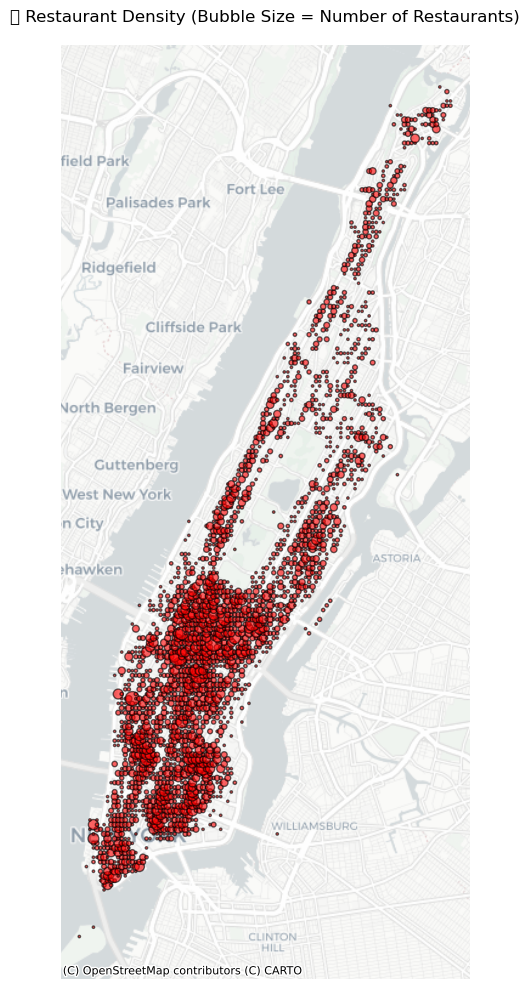

In [45]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
import contextily as ctx

# Step 1: Round lat/lon and group by location
df = restaurant_info.copy()
df['lat_rounded'] = df['lat'].round(3)
df['lon_rounded'] = df['lon'].round(3)
grouped = df.groupby(['lat_rounded', 'lon_rounded']).size().reset_index(name='count')

# Step 2: Convert to GeoDataFrame
geometry = [Point(xy) for xy in zip(grouped['lon_rounded'], grouped['lat_rounded'])]
gdf = gpd.GeoDataFrame(grouped, geometry=geometry, crs='EPSG:4326')  # WGS84

# Step 3: Reproject to Web Mercator for contextily basemap
gdf = gdf.to_crs(epsg=3857)

# Step 4: Plot
fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(
    ax=ax,
    markersize=gdf['count'] * 3,  # Adjust bubble size as needed
    alpha=0.6,
    color='red',
    edgecolor='black'
)

# Step 5: Add basemap and auto-zoom
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, crs=gdf.crs)
ax.set_title("📍 Restaurant Density (Bubble Size = Number of Restaurants)")
ax.set_axis_off()
plt.tight_layout()
plt.show()

# Fetch data for grid M-0417 and M-0319
- Focus on restaurant data in grid M-0417 and M-0319

## Get place_id

In [54]:
load_dotenv()
api_key = os.getenv("GOOGLE_API_KEY")

In [55]:
inspection_joined[inspection_joined['grid_id'].isin(['M-0417', 'M-0319'])].head()

,full_name,place_id,google_name,address,opening_hours,phone,rating,review_count,inspection_date,phone,...,business_hours,lat_rounded,lon_rounded,restaurant_counts,geometry,index_right,grid_id,lat_right,lon_right,predicted_level
35,SHUN LEE PALACE RESTAURANT 155 EAST 55 STREET,ChIJO8Bn7eRYwokRzpiMOXnARiU,Shun Lee Palace,"155 E 55th St, New York, NY 10022, USA",NaN,(212) 371-8844,3.8,315.0,2023-06-06,2123718844,...,"[{'open': [{'is_overnight': False, 'start': '1...",40.76,-73.97,437,POINT (-73.96948 40.75938),416,M-0417,40.7584,-73.9698,Level 5
112,RESTUARANT NIPPON 155 EAST 52 STREET,ChIJ88QfReNYwokRDwlvNwkIFVQ,Restaurant Nippon,"155 E 52nd St, New York, NY 10022, USA","Monday: 11:30 AM – 2:15 PM, 5:15 – 9:15 PM; Tu...",(212) 688-5941,4.5,287.0,2025-01-27,2126885941,...,"[{'open': [{'is_overnight': False, 'start': '1...",40.76,-73.97,437,POINT (-73.97088 40.75751),416,M-0417,40.7584,-73.9698,Level 5
238,LA GIOCONDA 226 EAST 53 STREET,NaN,NaN,NaN,NaN,NaN,4.0,221.0,2024-06-04,2123713536,...,"[{'open': [{'is_overnight': False, 'start': '1...",40.76,-73.97,437,POINT (-73.96865 40.75737),416,M-0417,40.7584,-73.9698,Level 5
266,PEKING DUCK HOUSE 236 EAST 53 STREET,NaN,NaN,NaN,NaN,NaN,3.4,562.0,2024-03-22,2127598260,...,"[{'open': [{'is_overnight': False, 'start': '1...",40.76,-73.97,437,POINT (-73.96849 40.75731),416,M-0417,40.7584,-73.9698,Level 5
804,P.J. CLARKE'S 915 3 AVENUE,NaN,NaN,NaN,NaN,NaN,3.7,1112.0,2025-01-27,2123171616,...,"[{'open': [{'is_overnight': False, 'start': '1...",40.76,-73.97,437,POINT (-73.96841 40.75904),416,M-0417,40.7584,-73.9698,Level 5


In [285]:
# Fetch place IDs for target grids
# Cells below has been executed

# target_grids = inspection_joined[inspection_joined['grid_id'].isin(['M-0417', 'M-0319'])]
# for i, row in target_grids.iterrows():
#     if pd.notna(row['place_id']):
#         print(f"{row['full_name']} place_id exists: {row['place_id']}")
#         continue

#     place_id = fetch_google_place_id(api_key=api_key,
#                                      place_name=row['full_name'])

#     inspection_joined.at[i, 'place_id'] = place_id
#     print(i, row['full_name'], place_id)
# inspection_joined.to_csv(f'restaurant_info.csv', index=False)

SHUN LEE PALACE RESTAURANT 155 EAST   55 STREET place_id exists: ChIJO8Bn7eRYwokRzpiMOXnARiU
RESTUARANT NIPPON 155 EAST   52 STREET place_id exists: ChIJ88QfReNYwokRDwlvNwkIFVQ
LA GIOCONDA 226 EAST   53 STREET place_id exists: ChIJ15B1duNYwokRY6etRnGuko0
266 PEKING DUCK HOUSE 236 EAST   53 STREET ChIJPQ1UmeNYwokRJ2mMjQeUL_I
804 P.J. CLARKE'S 915 3 AVENUE ChIJu4DTYeRYwokRHjDHAffrjeY
853 BOBBY VAN'S STEAKHOUSE 131 EAST   54 STREET ChIJf1CFs-RYwokR2QuIWC2THl8
905 CHIPOTLE MEXICAN GRILL 150 EAST   52 STREET ChIJaUU_cGtZwokRZgr82FA_I7k
POCHA 32 15 WEST   32 STREET place_id exists: ChIJJdmP46hZwokRqffbVAebL6s
1297 TOMI JAZZ 239 EAST   53 STREET ChIJVcSnm-NYwokRnGivcMPc81Q
AYZA CAFE & WINE BAR 11 WEST   31 STREET place_id exists: ChIJNw7LkqhZwokRnBhQLw_RyFM
WOORIJIP 12 WEST   32 STREET place_id exists: ChIJzfG-8ahZwokR5FLB4KmxBXI
1381 CLUB WYNN - GERA GERA 238 EAST   53 STREET ChIJkZWMnuNYwokRuIsRTguRun0
1383 REED SMITH 599 LEXINGTON AVENUE ChIJ6fUPUeNYwokR66jdsBZZTek
GAGOPA KARAOKE 28 WEST  

## Get other information

In [61]:
restaurant_info = pd.read_csv('restaurant_info.csv')
restaurant_info = restaurant_info[['full_name', 'place_id', 'google_name', 'address',
                                   'phone.1', 'rating', 'review_count', 'inspection_date', 
                                   'inspection_grade', 'cuisine_type', 'lat_left', 'lon_left',
                                   'cuisine_keyword', 'image_url', 'lat_rounded',
                                   'lon_rounded', 'restaurant_counts', 'geometry',
                                   'grid_id', 'predicted_level']]
restaurant_info = restaurant_info.rename(columns={'phone.1': 'phone',
                                                  'lat_left': 'lat', 
                                                  'lon_left': 'lon'})

In [74]:
full_popularity_df = pd.read_csv('google_api_restaurant_popular_time_step2.csv')
full_popularity_df = full_popularity_df.drop_duplicates(subset=['place_id', 'day'])

In [90]:
target_ones = restaurant_info[restaurant_info['google_name'].isna() & (restaurant_info['place_id'].str.len() > 10)]
for i, row in target_ones.iterrows():
    place_id = row['place_id']
    
    if row.get('google_name') is True:
        print(f"{row['place_id']} has been processed")
        continue

    try:
        response = populartimes.get_id(api_key=api_key, place_id=place_id)
        place_info_df, popularity_df = gen_place_info_popularity_df(response)

        restaurant_info.at[i, 'google_name'] = place_info_df.at[0, 'name']
        restaurant_info.at[i, 'address'] = place_info_df.at[0, 'address']
        restaurant_info.at[i, 'rating'] = place_info_df.at[0, 'rating']
        restaurant_info.at[i, 'review_count'] = place_info_df.at[0, 'review_count']
        
        full_popularity_df = pd.concat([full_popularity_df, popularity_df])
        print(f"{i}, {row['place_id']} successfully fetched!")

    except Exception as e:
        print(f"❌ Failed at row {i} (place_id={place_id}): {e}")
        continue

1343, ChIJX4lqiq9ZwokRyI0fufmrJLI successfully fetched!
1494, ChIJ6wb1E7BZwokRkegC09syV9Y successfully fetched!
2225, ChIJw5VsWosOZ0gReBrMdII0El4 successfully fetched!
2326, ChIJ_xUY2qhZwokRDDqPeRtPQJM successfully fetched!
3168, ChIJ27alQQBZwokR4B73wKiALog successfully fetched!
3419, ChIJpdSDcq5ZwokRazrue5ZXJ4I successfully fetched!
3426, ChIJ63UOFa5ZwokR195FnTIXPcc successfully fetched!
3427, ChIJpdSDcq5ZwokRazrue5ZXJ4I successfully fetched!
3435, ChIJ5XrvGa5ZwokRVFbhYo--qW8 successfully fetched!
3479, ChIJpdSDcq5ZwokRazrue5ZXJ4I successfully fetched!
4000, ChIJCTKiHq9ZwokR8iBJtG6i2DI successfully fetched!
4103, ChIJX3vA5ahZwokRd9ZnszaGXFM successfully fetched!
4784, ChIJiYcVzRJZwokRfw8qFE8eJq0 successfully fetched!
5799, ChIJYWYX-q5ZwokR5mxMnmEer5g successfully fetched!
6743, ChIJqw9IQ05ZwokRS8MvajLr6fw successfully fetched!
7163, ChIJX3f5cwhZwokR0pSMyeDcS9U successfully fetched!
7239, ChIJCSs__TZZwokRcz9q4h0Wyu8 successfully fetched!
7384, ChIJw5VsWosOZ0gReBrMdII0El4 successfully f

In [91]:
# restaurant_info.to_csv('restaurant_info.csv', index=False)
# full_popularity_df.to_csv('restaurant_popular_hour.csv', index=False)

## Fix missing place ID

In [107]:
target_ones = restaurant_info[(restaurant_info['grid_id'].isin(['M-0417', 'M-0319'])) & (restaurant_info['place_id'].str.len() < 10)]

for i, row in target_ones.iterrows():
    place_name = row['full_name'] + ', New York'
    place_id = fetch_google_place_id(api_key=api_key,
                                     place_name=place_name)

    restaurant_info.at[i, 'place_id'] = place_id
    print(i, row['full_name'], place_id)

3401 OMAR'S MEDITERRANEAN CUISINE 154 EAST   55 STREET ChIJU2zak-RYwokRNvszpehgiIs
4023 ITAVOLO 875 3 AVENUE ChIJR_ywb-NYwokRe7kUDysgQlY
4144 THE MILL 140 EAST   52 STREET ChIJAxpMs_xYwokRzNtZQbtlPpo
4461 TABLE 866 @ COURTYARD MARRIOTT 866 3 AVENUE ChIJB1QFaONYwokRd566RKNxjbM
4819 WILDCARD BAR 238 EAST   53 STREET ChIJcQueDS5ZwokRGZ5_qyESs3I
5425 LE JARDINIERE 610 LEXINGTON AVENUE ChIJKdcKCelZwokRdFHp3hzUKok
6283 HIMALAYAN CURRY HOUSE 220 EAST   53 STREET ChIJbwUoi_FZwokRl48VBignQI8
6312 ETC VENUES 153 EAST   53 STREET ChIJ1fYXxupZwokRTHvImc6tF9I
6663 KAZUNORI 601 LEXINGTON AVENUE ChIJMQAQo4VZwokRXOvgCSA_5-U
6769 JUMIEKA 601 LEXINGTON AVENUE ChIJwdTFRlRZwokRVOfab8Qm9uw
7243 XENO'S PIZZA 163 EAST   52 STREET ChIJEc0wLSdZwokRpjSOhIt8NA8
8533 Angelina Gelateria 6 WEST   32 STREET ChIJDWuo3X9ZwokRRoQw7al1Ayw
9088 CAFE JOYEUX 599 LEXINGTON AVENUE ChIJ0WO-IgBZwokR6QhRi-jcXpg
9390 EPICERIE BOULUD 885 3 AVENUE ChIJlVRW8ytZwokRed1ILAFciVA
10313 HOLY COW 906 3 AVENUE ChIJB_eItiFZwokRXTQSgPVzPjY


In [110]:
# target_ones = restaurant_info[restaurant_info['google_name'].isna() & (restaurant_info['place_id'].str.len() > 10)]
# for i, row in target_ones.iterrows():
#     place_id = row['place_id']
    
#     if row.get('google_name') is True:
#         print(f"{row['place_id']} has been processed")
#         continue

#     try:
#         response = populartimes.get_id(api_key=api_key, place_id=place_id)
#         place_info_df, popularity_df = gen_place_info_popularity_df(response)

#         restaurant_info.at[i, 'google_name'] = place_info_df.at[0, 'name']
#         restaurant_info.at[i, 'address'] = place_info_df.at[0, 'address']
#         restaurant_info.at[i, 'rating'] = place_info_df.at[0, 'rating']
#         restaurant_info.at[i, 'review_count'] = place_info_df.at[0, 'review_count']
        
#         full_popularity_df = pd.concat([full_popularity_df, popularity_df])
#         print(f"{i}, {row['place_id']} successfully fetched!")

#     except Exception as e:
#         print(f"❌ Failed at row {i} (place_id={place_id}): {e}")
#         continue
# restaurant_info.to_csv('restaurant_info.csv', index=False)
# full_popularity_df.to_csv('restaurant_popular_hour.csv', index=False)

3401, ChIJU2zak-RYwokRNvszpehgiIs successfully fetched!
4023, ChIJR_ywb-NYwokRe7kUDysgQlY successfully fetched!
4144, ChIJAxpMs_xYwokRzNtZQbtlPpo successfully fetched!
4461, ChIJB1QFaONYwokRd566RKNxjbM successfully fetched!
4819, ChIJcQueDS5ZwokRGZ5_qyESs3I successfully fetched!
5425, ChIJKdcKCelZwokRdFHp3hzUKok successfully fetched!
6283, ChIJbwUoi_FZwokRl48VBignQI8 successfully fetched!
6312, ChIJ1fYXxupZwokRTHvImc6tF9I successfully fetched!
6663, ChIJMQAQo4VZwokRXOvgCSA_5-U successfully fetched!
6769, ChIJwdTFRlRZwokRVOfab8Qm9uw successfully fetched!
7243, ChIJEc0wLSdZwokRpjSOhIt8NA8 successfully fetched!
8533, ChIJDWuo3X9ZwokRRoQw7al1Ayw successfully fetched!
9088, ChIJ0WO-IgBZwokR6QhRi-jcXpg successfully fetched!
9390, ChIJlVRW8ytZwokRed1ILAFciVA successfully fetched!
10313, ChIJB_eItiFZwokRXTQSgPVzPjY successfully fetched!


In [163]:
restaurant_info[(restaurant_info['predicted_level'] == 'Level 5')].groupby('grid_id').size().sort_values(ascending=False).head()

grid_id
M-0351    102
M-0417     95
M-0319     86
M-0374     62
M-0212     59
dtype: int64

# Fetch data for grid M-0351

In [247]:
restaurant_info = pd.read_csv('restaurant_info.csv')
popular_hour = pd.read_csv('restaurant_popular_hour.csv')
opening_hour = pd.read_csv('restaurant_opening_hour.csv')

In [248]:
restaurant_info.groupby(['grid_id', 'predicted_level'])['full_name'].size().sort_values()

grid_id  predicted_level
M-0020   Not Level 5          1
M-0717   Not Level 5          1
M-0688   Not Level 5          1
M-0680   Not Level 5          1
M-0666   Not Level 5          1
                           ... 
M-0045   Not Level 5         71
M-0319   Level 5             86
M-0188   Not Level 5         88
M-0417   Level 5             95
M-0351   Level 5            102
Name: full_name, Length: 675, dtype: int64

In [249]:
load_dotenv()
google_api_key = os.getenv("GOOGLE_API_KEY")

In [252]:
# Target: records in M-0351 and have invalid place_id
target_ones = restaurant_info[(restaurant_info['grid_id'].isin(['M-0351'])) & (restaurant_info['place_id'].str.len() < 10)]
for i, row in target_ones.iterrows():
    if pd.notna(row['place_id']):
        print(f"{row['full_name']} place_id exists: {row['place_id']}")
        continue
    place_name = row['full_name'] + ', New York'
    place_id = fetch_google_place_id(api_key=google_api_key,
                                     place_name=place_name)

    restaurant_info.at[i, 'place_id'] = place_id
    print(i, row['full_name'], place_id)

3403 THEATER (FLY) 4 PENN PLZ False
3406 BT4 AISLE B 4 PENN PLZ ChIJ63UOFa5ZwokR195FnTIXPcc
3407 GOLD BAR A BT5 4 PENN PLZ ChIJL0o4MC9ZwokRtczmhExrQDA
3408 GOLD BAR B BT6 4 PENN PLZ ChIJL0o4MC9ZwokRtczmhExrQDA
3409 CHASE LOUNGE - 3rd Floor 4 PENN PLZ ChIJKUd-qXBZwokRbjkO63jvgMk
3412 BT3 AISLE A 4 PENN PLZ ChIJEdcW9a5ZwokR_dQ30akbkU8
3413 HOT DOG CONCESSION 4 PENN PLZ ChIJ9_3t_H5ZwokRuZkBPX99Keo
3416 BAR GARDEN 4 PENN PLZ ChIJJXfoP65ZwokR7mj2Skb3LAs
3417 BAR - (BD6130) 4 PENN PLZ ChIJJXfoP65ZwokR7mj2Skb3LAs
3424 PIZZA CONCESSION 4 PENN PLZ ChIJjaD94kFZwokR-20CXqlpy_4
3425 THE SHACK - CB8030 (CB8040) 4 PENN PLZ ChIJsVlEJHJZwokR_tRiLcGukN8
3429 MIGHTY QUINN'S BBQ - FA8032 (CA8033) 4 PENN PLZ ChIJnRjKm6tZwokRge1J396OZig
3430 GARDEN MARKET EXPRESS - FA8150 4 PENN PLZ ChIJLcNSI65ZwokR9kkzuSIdWGo
3432 BAR 4 PENN PLZ ChIJJXfoP65ZwokR7mj2Skb3LAs
3433 GARDEN MARKET HOT DOG CONCESSION 4 PENN PLZ ChIJLcNSI65ZwokR9kkzuSIdWGo
3437 HOT DOG CONCESSION, GARDEN MARKET 4 PENN PLZ ChIJ4yzW6R5ZwokRvROlPlNU

In [261]:
# Target: records in M-0351 and have missing place_id
target_ones = restaurant_info[(restaurant_info['grid_id'].isin(['M-0351'])) & restaurant_info['place_id'].isna()]
for i, row in target_ones.iterrows():
    if pd.notna(row['place_id']):
        print(f"{row['full_name']} place_id exists: {row['place_id']}")
        continue
    place_name = row['full_name'] + ', New York'
    place_id = fetch_google_place_id(api_key=google_api_key,
                                     place_name=place_name)

    restaurant_info.at[i, 'place_id'] = place_id
    print(i, row['full_name'], place_id)

481 KABOOZ'S BAR & GRILLE 0 AMTRAK LEVEL False


In [266]:
# Target: records in M-0351 and have valid place_id
target_ones = restaurant_info[(restaurant_info['grid_id'].isin(['M-0351'])) & (restaurant_info['google_name'].isna()) & (restaurant_info['place_id'].str.len() > 10)]

for i, row in target_ones.iterrows():
    place_id = row['place_id']
    
    if row.get('google_name') is True:
        print(f"{row['place_id']} has been processed")
        continue

    try:
        response = populartimes.get_id(api_key=google_api_key, place_id=place_id)
        place_info_df, popularity_df = gen_place_info_popularity_df(response)

        restaurant_info.at[i, 'google_name'] = place_info_df.at[0, 'name']
        restaurant_info.at[i, 'address'] = place_info_df.at[0, 'address']
        restaurant_info.at[i, 'rating'] = place_info_df.at[0, 'rating']
        restaurant_info.at[i, 'review_count'] = place_info_df.at[0, 'review_count']
        
        popular_hour = pd.concat([popular_hour, popularity_df])
        print(f"{i}, {row['place_id']} successfully fetched!")

    except Exception as e:
        print(f"❌ Failed at row {i} (place_id={place_id}): {e}")
        continue

3406, ChIJ63UOFa5ZwokR195FnTIXPcc successfully fetched!
3407, ChIJL0o4MC9ZwokRtczmhExrQDA successfully fetched!
3408, ChIJL0o4MC9ZwokRtczmhExrQDA successfully fetched!
3409, ChIJKUd-qXBZwokRbjkO63jvgMk successfully fetched!
3412, ChIJEdcW9a5ZwokR_dQ30akbkU8 successfully fetched!
3413, ChIJ9_3t_H5ZwokRuZkBPX99Keo successfully fetched!
3416, ChIJJXfoP65ZwokR7mj2Skb3LAs successfully fetched!
3417, ChIJJXfoP65ZwokR7mj2Skb3LAs successfully fetched!
3424, ChIJjaD94kFZwokR-20CXqlpy_4 successfully fetched!
3425, ChIJsVlEJHJZwokR_tRiLcGukN8 successfully fetched!
3429, ChIJnRjKm6tZwokRge1J396OZig successfully fetched!
3430, ChIJLcNSI65ZwokR9kkzuSIdWGo successfully fetched!
3432, ChIJJXfoP65ZwokR7mj2Skb3LAs successfully fetched!
3433, ChIJLcNSI65ZwokR9kkzuSIdWGo successfully fetched!
3437, ChIJ4yzW6R5ZwokRvROlPlNUXd0 successfully fetched!
3438, ChIJLcNSI65ZwokR9kkzuSIdWGo successfully fetched!
3443, ChIJ63UOFa5ZwokR195FnTIXPcc successfully fetched!
3445, ChIJKaKVI79ZwokRN8WicODOIAw successfully f

In [273]:
popular_hour = popular_hour.drop_duplicates(subset=['place_id', 'day'])
restaurant_info.to_csv('restaurant_info.csv', index=False)
popular_hour.to_csv('restaurant_popular_hour.csv', index=False)

# View Current Status

In [12]:
restaurant_info = pd.read_csv('restaurant_info.csv')
popular_hour = pd.read_csv('restaurant_popular_hour.csv')
opening_hour = pd.read_csv('restaurant_opening_hour.csv')

In [13]:
restaurant_info.groupby(['grid_id', 'predicted_level'])['full_name'].size().sort_values()

grid_id  predicted_level
M-0020   Not Level 5          1
M-0717   Not Level 5          1
M-0688   Not Level 5          1
M-0680   Not Level 5          1
M-0666   Not Level 5          1
                           ... 
M-0045   Not Level 5         71
M-0319   Level 5             86
M-0188   Not Level 5         88
M-0417   Level 5             95
M-0351   Level 5            102
Name: full_name, Length: 675, dtype: int64

In [14]:
restaurant_info[restaurant_info['google_name'].notna()].groupby(['grid_id', 'predicted_level'])['full_name'].size().sort_values()

grid_id  predicted_level
M-0046   Not Level 5         1
M-0473   Not Level 5         1
M-0461   Not Level 5         1
M-0460   Not Level 5         1
M-0459   Level 5             1
                            ..
M-0352   Level 5            50
M-0372   Not Level 5        52
M-0319   Level 5            86
M-0417   Level 5            95
M-0351   Level 5            97
Name: full_name, Length: 153, dtype: int64

In [20]:
restaurant_info['has_popular_hour_data'] = restaurant_info['place_id'].isin(popular_hour['place_id'])
restaurant_info['has_opening_hour_data'] = restaurant_info['full_name'].isin(opening_hour['full_name'])
restaurant_info.to_csv('restaurant_info.csv', index=False)

In [21]:
cond1 = restaurant_info['google_name'].notna()
cond2 = restaurant_info['predicted_level'] == 'Level 5'
cond3 = restaurant_info['image_url'].notna()
restaurant_info[cond1 & cond2 & cond3]

,full_name,place_id,google_name,address,phone,rating,review_count,inspection_date,inspection_grade,cuisine_type,...,cuisine_keyword,image_url,lat_rounded,lon_rounded,restaurant_counts,geometry,grid_id,predicted_level,has_popular_hour_data,has_opening_hour_data
7,ISLE OF CAPRI RESTURANT 1028 3 AVENUE,ChIJpRVGV-9YwokRHnDd6TD7qxQ,Isle of Capri,"1028 3rd Ave, New York, NY 10065, USA",2127581902,4.5,507.0,2024-09-10,NaN,Italian,...,"[{'alias': 'italian', 'title': 'Italian'}]",https://s3-media2.fl.yelpcdn.com/bphoto/IVhVHl...,40.76,-73.97,437,POINT (-73.965749576014 40.76270773611),M-0459,Level 5,False,True
15,OLD HOMESTEAD 56 9 AVENUE,ChIJ7-2lDL9ZwokRvzpIH3Etebo,Old Homestead Steakhouse,"56 9th Ave, New York, NY 10011, USA",2122429040,4.1,2300.0,2023-03-23,A,American,...,"[{'alias': 'steak', 'title': 'Steakhouses'}]",https://s3-media1.fl.yelpcdn.com/bphoto/fKuSMG...,40.74,-74.01,109,POINT (-74.005037755098 40.741372224356),M-0269,Level 5,False,True
26,PATSY'S ITALIAN RESTAURANT 236 WEST 56 STREET,ChIJ22yt_PdYwokRFf4cnErij6k,Patsy's Italian Restaurant,"236 W 56th St, New York, NY 10019, USA",2122473491,4.3,1954.0,2023-12-28,A,Italian,...,"[{'alias': 'italian', 'title': 'Italian'}, {'a...",https://s3-media3.fl.yelpcdn.com/bphoto/vuP2Xm...,40.77,-73.98,174,POINT (-73.98239751366 40.765618195284),M-0474,Level 5,False,True
33,TIO PEPE 168 WEST 4 STREET,ChIJP9QbH5HGDQ0R7d77RhLqFOQ,Bodega Tio Pepe,"C. Manuel María González, 12, 11403 Jerez de l...",2122429338,4.2,1495.0,2023-12-05,A,Seafood,...,"[{'alias': 'spanish', 'title': 'Spanish'}, {'a...",https://s3-media4.fl.yelpcdn.com/bphoto/fDmnyy...,40.73,-74.00,490,POINT (-74.001443280258 40.732056597098),M-0212,Level 5,False,True
35,SHUN LEE PALACE RESTAURANT 155 EAST 55 STREET,ChIJO8Bn7eRYwokRzpiMOXnARiU,Shun Lee Palace,"155 E 55th St, New York, NY 10022, USA",2123718844,3.8,315.0,2023-06-06,A,Chinese,...,"[{'alias': 'chinese', 'title': 'Chinese'}]",https://s3-media1.fl.yelpcdn.com/bphoto/Fmv9X1...,40.76,-73.97,437,POINT (-73.96948371139 40.759376653074),M-0417,Level 5,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10088,PAPI PASTA & PIZZA 485 7 AVENUE,ChIJ94hxiL2vQjQR5H7l0jecDus,Papa Vito Kitchen,"111, Taiwan, Taipei City, Shilin District, Lan...",6468990285,4.8,0.0,2025-03-31,A,Pizza,...,"[{'alias': 'pizza', 'title': 'Pizza'}, {'alias...",https://s3-media2.fl.yelpcdn.com/bphoto/W7YOSk...,40.75,-73.99,676,POINT (-73.989543829055 40.752457950673),M-0352,Level 5,False,True
10163,ANGELINA BAKERY NOMAD 42 WEST 28 STREET,ChIJZ4m18qdZwokRVNjfHKJdHC8,Angelina Bakery Nomad,"42 W 28th St Ground Floor, New York, NY 10001,...",6466675285,4.6,104.0,2025-02-26,A,Bakery Products/Desserts,...,"[{'alias': 'bakeries', 'title': 'Bakeries'}, {...",https://s3-media3.fl.yelpcdn.com/bphoto/5ZXnas...,40.75,-73.99,676,POINT (-73.989357255146 40.745535645923),M-0303,Level 5,True,True
10337,LIBERTY BAGELS 260 WEST 35 STREET,ChIJEWqQDLJZwokR8K5wVBL9n6g,Liberty Bagels Midtown,"260 W 35th St, New York, NY 10001, USA",2122791124,4.6,4000.0,2025-04-24,N,Bagels/Pretzels,...,"[{'alias': 'breakfast_brunch', 'title': 'Break...",https://s3-media3.fl.yelpcdn.com/bphoto/kkkc0M...,40.75,-73.99,676,POINT (-73.991785225474 40.752337363573),M-0352,Level 5,True,True
10362,JONGRO BBQ MARKET 39 WEST 32 STREET,ChIJvww8eL5ZwokRRbZwZCjAlb8,Jongro BBQ Market | Best All You Can Eat Korea...,"39 W 32nd St 1st Fl, New York, NY 10001, USA",2128842330,4.6,0.0,2025-04-28,N,Korean,...,"[{'alias': 'korean', 'title': 'Korean'}, {'ali...",https://s3-media3.fl.yelpcdn.com/bphoto/8ez64l...,40.75,-73.99,676,POINT (-73.986650130485 40.747646084632),M-0319,Level 5,False,True


# Test Cases

## Case 1: Old Homestead Steakhouse
- Location:
- Filter: Amercian
- Choose "Puttery" to show review_counts, rating, and popular hours

In [114]:
restaurant_info = gen_distance_to_case(restaurant_df=restaurant_info,
                                       case_google_name='Old Homestead Steakhouse')

'distance_to_old_homestead_steakhouse'

In [116]:
cond1 = restaurant_info['distance_to_old_homestead_steakhouse'] <= 1
cond2 = restaurant_info['google_name'].isna()
cond3 = restaurant_info['cuisine_type'] == 'American'

In [54]:
load_dotenv()
google_api_key = os.getenv("GOOGLE_API_KEY")

In [56]:
# Target: American restaurants, close to Case 1 location (< 1 km)
target_ones = restaurant_info[cond1 & cond2 & cond3]
for i, row in target_ones.iterrows():
    if pd.notna(row['place_id']):
        print(f"{row['full_name']} place_id exists: {row['place_id']}")
        continue
    place_name = row['full_name'] + ', New York'
    place_id = fetch_google_place_id(api_key=google_api_key,
                                     place_name=place_name)
    restaurant_info.at[i, 'place_id'] = place_id
    print(i, row['full_name'], place_id)
restaurant_info.to_csv('restaurant_info.csv', index=False)

226 FLANNERY'S BAR 205 WEST   14 STREET ChIJt-G0571ZwokRWKqfW3zX8NU
261 BUS STOP CAFE 597 HUDSON STREET ChIJfdvZMJVZwokRMQq0PSULqp8
335 THE JOYCE THEATER 175 EIGHTH AVENUE ChIJ08b1_7tZwokRtbJxZjQbABM
354 BARRACUDA BAR 275 WEST   22 STREET ChIJg912rrtZwokRplCG3u0bCuo
404 REBAR 223 WEST   19 STREET ChIJ4cDNebxZwokRpktDMbgATW4
448 TAVERN ON JANE 31 8 AVENUE ChIJvZJQfZVZwokRMOpjuxvUDG4
451 HUDSON BAR AND BOOKS 636 HUDSON STREET ChIJs-fI479ZwokRecYht5wdRPk
452 LA BONBONNIERE 28 8 AVENUE ChIJj1NmZZVZwokRZ7t6RkyDV0o
459 HECTOR'S CAFE & DINER 44 LITTLE WEST   12 STREET ChIJfZw3R8BZwokRr6FJ2iNJX68
478 BOWLMOR CHELSEA PIERS 60 CHELSEA PIERS ChIJhXLJVXJZwokRwgRF71i8vIc
514 CAFETERIA 119 7 AVENUE ChIJ329uV7xZwokRfM6dcDcOtKY
530 SPIRIT OF NEW JERSEY PIER 62 WEST 23 STREET - CHELSEA PIER ChIJeSRQJLtZwokRX_b4Us3l72c
536 WESTSIDE TAVERN 360 WEST   23 STREET ChIJz0ZiiblZwokR0N8DMCLuor0
538 PIER 60 PIER 60 23RD STREET AND WEST SIDE HIGHWAY ChIJjT7O2sdZwokRPnmqePtjHrI
615 JULIUS 159 WEST   10 STREET ChIJ

In [67]:
# Target: American restaurants, close to Case 1 location (< 1 km)
cond1 = restaurant_info['distance_to_old_homestead_steakhouse'] <= 1
cond2 = restaurant_info['google_name'].isna()
cond3 = restaurant_info['cuisine_type'] == 'American'

# Target: records in M-0351 and have valid place_id
target_ones = restaurant_info[cond1 & cond2 & cond3]
print(popular_hour.shape)
for i, row in target_ones.iterrows():
    place_id = row['place_id']
    
    if row.get('google_name') is True:
        print(f"{row['place_id']} has been processed")
        continue

    try:
        response = populartimes.get_id(api_key=google_api_key, place_id=place_id)
        place_info_df, popularity_df = gen_place_info_popularity_df(response)

        restaurant_info.at[i, 'google_name'] = place_info_df.at[0, 'name']
        restaurant_info.at[i, 'address'] = place_info_df.at[0, 'address']
        restaurant_info.at[i, 'rating'] = place_info_df.at[0, 'rating']
        restaurant_info.at[i, 'review_count'] = place_info_df.at[0, 'review_count']
        
        popular_hour = pd.concat([popular_hour, popularity_df])
        print(f"{i}, {row['place_id']} successfully fetched!")

    except Exception as e:
        print(f"❌ Failed at row {i} (place_id={place_id}): {e}")
        continue
print(popular_hour.shape)

(3017, 26)
354, ChIJg912rrtZwokRplCG3u0bCuo successfully fetched!
404, ChIJ4cDNebxZwokRpktDMbgATW4 successfully fetched!
448, ChIJvZJQfZVZwokRMOpjuxvUDG4 successfully fetched!
451, ChIJs-fI479ZwokRecYht5wdRPk successfully fetched!
452, ChIJj1NmZZVZwokRZ7t6RkyDV0o successfully fetched!
459, ChIJfZw3R8BZwokRr6FJ2iNJX68 successfully fetched!
478, ChIJhXLJVXJZwokRwgRF71i8vIc successfully fetched!
514, ChIJ329uV7xZwokRfM6dcDcOtKY successfully fetched!
530, ChIJeSRQJLtZwokRX_b4Us3l72c successfully fetched!
536, ChIJz0ZiiblZwokR0N8DMCLuor0 successfully fetched!
538, ChIJjT7O2sdZwokRPnmqePtjHrI successfully fetched!
615, ChIJJ0KwSzBZwokRZBEwqbaFtjU successfully fetched!
676, ChIJYQgB1pRZwokRhUb5IBPEl6A successfully fetched!
730, ChIJqYlpjrlZwokRI62BYbAFgY8 successfully fetched!
735, ChIJe5cIzpdZwokRDDFm-wU9QgI successfully fetched!
749, ChIJ6-Yvh7xZwokRRwLG8NTqRQY successfully fetched!
781, ChIJKUCCVrpZwokRzavYvxNL6Jw successfully fetched!
809, ChIJs9RDeJZZwokRGrSKFEVs4o0 successfully fetched!

In [122]:
popular_hour = popular_hour.drop_duplicates(subset=['place_id', 'day'])
print(popular_hour.shape)
restaurant_info['has_popular_hour_data'] = restaurant_info['place_id'].isin(popular_hour['place_id'])
restaurant_info['has_opening_hour_data'] = restaurant_info['full_name'].isin(opening_hour['full_name'])
restaurant_info.to_csv('restaurant_info.csv', index=False)
popular_hour.to_csv('restaurant_popular_hour.csv', index=False)

In [124]:
cond1 = restaurant_info['distance_to_old_homestead_steakhouse'] <= 1
cond2 = restaurant_info['has_popular_hour_data'] == True
cond3 = restaurant_info['cuisine_type'] == 'American'
cond4 = restaurant_info['predicted_level'] == 'Level 5'
cond5 = restaurant_info['image_url'].notna()
restaurant_info[cond1 & cond2 & cond3 & cond4 & cond5].sort_values('distance_to_old_homestead_steakhouse').head()
# restaurant_info[cond1 & cond2 & cond3 & cond4].sort_values('distance_km_case1').head().T

,full_name,place_id,google_name,address,phone,rating,review_count,inspection_date,inspection_grade,cuisine_type,...,lat_rounded,lon_rounded,restaurant_counts,geometry,grid_id,predicted_level,has_popular_hour_data,has_opening_hour_data,distance_to_fairfax,distance_to_old_homestead_steakhouse
9273,PUTTERY 446 WEST 14 STREET,ChIJUxpywGVZwokRIvAIwd-hcrc,Puttery,"446 W 14th St, New York, NY 10014, USA",3106644295,4.4,467.0,2025-02-26,A,American,...,40.74,-74.01,109,POINT (-74.007387069229 40.741783811569),M-0282,Level 5,True,True,0.9059,0.2031
3589,FAIRFAX 234 WEST 4 STREET,ChIJSyYvYZRZwokR6tWSvOA2xXw,Fairfax,"234 W 4th St, New York, NY 10014, USA",2123210298,4.5,527.0,2025-02-10,A,American,...,40.73,-74.00,490,POINT (-74.003009342992 40.734342955714),M-0227,Level 5,True,True,0.0000,0.8001
4388,DUE WEST 189 WEST 10 STREET,ChIJEyUgYZRZwokRETFRosKubF8,Due West,"189 W 10th St, New York, NY 10014, USA",6466874609,4.2,357.0,2023-01-26,A,American,...,40.73,-74.00,490,POINT (-74.003200578258 40.734219436137),M-0227,Level 5,True,True,0.0212,0.8103
6546,St Jardim 183 WEST 10 STREET,ChIJQT7u80BZwokR5MLuGvTsBiY,St Jardim,"183 W 10th St, New York, NY 10014, USA",5125606933,4.5,311.0,2025-02-06,A,American,...,40.73,-74.00,490,POINT (-74.002803665805 40.734279831343),M-0227,Level 5,True,True,0.0187,0.8108
948,HOLLYWOOD DINER 574 6 AVENUE,ChIJyVUxOr1ZwokR2NrMdyEQnWY,Hollywood Diner,"574 6th Ave, New York, NY 10011, USA",2126918465,3.9,1413.0,2024-07-17,A,American,...,40.74,-74.00,316,POINT (-73.99576715008 40.738808648069),M-0257,Level 5,True,True,0.7867,0.8314


In [83]:
restaurant_info[restaurant_info['google_name'] == 'Puttery']['image_url'].iloc[0]

'https://s3-media2.fl.yelpcdn.com/bphoto/xlqa8LyxytJHqhk_KrZLvg/o.jpg'

In [88]:
restaurant_info.groupby(['cuisine_type']).size().sort_values()

cuisine_type
Haute Cuisine       1
Creole              1
Basque              1
Indonesian          2
Soups               2
                 ... 
Chinese           494
Japanese          517
Italian           585
Coffee/Tea       1084
American         2489
Length: 84, dtype: int64

## Case 2: Fairfax (better than Case 1)
- Location: Fairfax
- Filter: American
- Can choose "Fairfax" and "St Jardim" to demo complete data

In [109]:
restaurant_info = gen_distance_to_case(restaurant_df=restaurant_info,
                                       case_google_name='Fairfax')

'distance_to_fairfax'

In [133]:
cond1 = restaurant_info['distance_to_fairfax'] <= 1
cond2 = restaurant_info['google_name'].isna()
cond3 = restaurant_info['cuisine_type'] == 'American'
restaurant_info[cond1 & cond3].sort_values('distance_to_fairfax').head(10).T

,3589,1009,6546,3927,4388,6433,5114,940,947,2882
full_name,FAIRFAX 234 WEST 4 STREET,SMALLS JAZZ CLUB 183 WEST 10 STREET,St Jardim 183 WEST 10 STREET,WHILE WE WERE YOUNG 183 WEST 10 STREET,DUE WEST 189 WEST 10 STREET,CELLAR DOG 75 CHRISTOPHER STREET,DUNKIN 75 CHRISTOPHER STREET,THE DUPLEX 61 CHRISTOPHER STREET,KETTLE OF FISH 59 CHRISTOPHER STREET,MEZZROW 163 WEST 10 STREET
place_id,ChIJSyYvYZRZwokR6tWSvOA2xXw,ChIJu55raJRZwokReRL9b1tLmQo,ChIJQT7u80BZwokR5MLuGvTsBiY,ChIJZRslaJRZwokRgVlMzbgFTus,ChIJEyUgYZRZwokRETFRosKubF8,ChIJhWENSQ1ZwokRuuh2eZNUUSc,ChIJ3bKqfpRZwokRD0tUBRYPKPk,ChIJw-gIcpRZwokRz2K4g1SPOS4,ChIJk7eGbZRZwokRx6UUE0oExXk,ChIJzYwpP5RZwokRk_zUBWseSBY
google_name,Fairfax,Smalls Jazz Club,St Jardim,While We Were Young Kitchen & Cocktails,Due West,Cellar Dog,Dunkin',The Duplex,Kettle of Fish,Mezzrow
address,"234 W 4th St, New York, NY 10014, USA","183 W 10th St, New York, NY 10014, USA","183 W 10th St, New York, NY 10014, USA","183 W 10th St, New York, NY 10014, USA","189 W 10th St, New York, NY 10014, USA","75 Christopher St, New York, NY 10014, USA","75 Christopher St, New York, NY 10014, USA","61 Christopher St, New York, NY 10014, USA","59 Christopher St, New York, NY 10014, USA","163 W 10th St, New York, NY 10014, USA"
phone,2123210298,6468230596,5125606933,9176756272,6466874609,2126756056,2126913138,2122555438,2124142278,6464764346
rating,4.5,4.6,4.5,4.3,4.2,4.3,3.8,4.4,4.5,4.6
review_count,527.0,3364.0,311.0,302.0,357.0,590.0,114.0,1196.0,493.0,1226.0
inspection_date,2025-02-10,2024-08-20,2025-02-06,2020-01-23,2023-01-26,2023-11-02,2024-09-13,2023-04-14,2023-12-07,2023-12-14
inspection_grade,A,A,A,NaN,A,A,A,A,A,A
cuisine_type,American,American,American,American,American,American,American,American,American,American


## Case 3: Stella 34 Trattoria
- location: Stella 34 Trattoria
- Filter: Italian
- Demo: Arno, Stella 34 Trattoria

In [136]:
restaurant_info = gen_distance_to_case(restaurant_df=restaurant_info,
                                       case_google_name='Stella 34 Trattoria')

'distance_to_stella_34_trattoria'

In [139]:
cond1 = restaurant_info['cuisine_type'] == 'Italian'
cond2 = restaurant_info['distance_to_stella_34_trattoria'] < 1
restaurant_info[cond1 & cond2].sort_values('distance_to_stella_34_trattoria').shape

(52, 25)

In [140]:
# Target: Italian restaurants, close to Stella 34 Trattoria (<1 km)
cond1 = restaurant_info['cuisine_type'] == 'Italian'
cond2 = restaurant_info['distance_to_stella_34_trattoria'] < 1
target_ones = restaurant_info[cond1 & cond2]

for i, row in target_ones.iterrows():
    if pd.notna(row['place_id']):
        print(f"{row['full_name']} place_id exists: {row['place_id']}")
        continue
    place_name = row['full_name'] + ', New York'
    place_id = fetch_google_place_id(api_key=google_api_key,
                                     place_name=place_name)
    restaurant_info.at[i, 'place_id'] = place_id
    print(i, row['full_name'], place_id)
restaurant_info.to_csv('restaurant_info.csv', index=False)

ROSSINI'S 108 EAST   38 STREET place_id exists: ChIJV6mJyQZZwokRPoUsJJjsgoI
VILLA BERULIA 107 EAST   34 STREET place_id exists: ChIJe14KpQdZwokReRadKUwTRSM
SALUMERIA BEILLESE, BIRICCHINO REST 378 8 AVENUE place_id exists: ChIJOye_hUpFwokRCQtz1KwJjUw
ARNO RISTORANTE 141 WEST   38 STREET place_id exists: ChIJV0bfnqtZwokRo0b29CRqsS8
216 CARMINE'S 200 WEST   44 STREET ChIJR9So-lRYwokRX1xEjA0rChA
TRATTORIA BIANCA 481 8 AVENUE place_id exists: ChIJGwGp6q1ZwokRZAEGF2dtd9c
797 TONY'S DI NAPOLI 147 WEST   43 STREET ChIJVS2qI1VYwokRFo18YsKvHYM
873 MANGIA 22 WEST   23 STREET ChIJiYHlc6RZwokRFEXSBHqZ6cg
1398 CASA DI ISACCO 536 9 AVENUE ChIJZRMgtFJYwokR4osypSsVIeo
1583 MERCATO 352 WEST   39 STREET ChIJaR8ATK1ZwokR8w8YRQ_lQOw
1811 IL PUNTO RISTORANTE 507509 9 AVENUE ChIJw1QgWK1ZwokRnOR94NZ1i8w
1854 OSTERIA AL DOGE 142 WEST   44 STREET ChIJe-MbFlVYwokRIPak_2F4KzY
1871 AI FIORI 400 5 AVENUE ChIJMYIE-KlZwokRZuFHn8jkNuo
1888 SERGIMMO SALUMERIA 456 9 AVENUE ChIJwWgpfbJZwokRjhUUSx081xA
1977 SERRA by BIRRE

In [141]:
# Target: Italian restaurants, close to Stella 34 Trattoria (<1 km)
cond1 = restaurant_info['cuisine_type'] == 'Italian'
cond2 = restaurant_info['distance_to_stella_34_trattoria'] < 1
target_ones = restaurant_info[cond1 & cond2]

print(popular_hour.shape)
for i, row in target_ones.iterrows():
    place_id = row['place_id']
    
    if row.get('google_name') is True:
        print(f"{row['place_id']} has been processed")
        continue

    try:
        response = populartimes.get_id(api_key=google_api_key, place_id=place_id)
        place_info_df, popularity_df = gen_place_info_popularity_df(response)

        restaurant_info.at[i, 'google_name'] = place_info_df.at[0, 'name']
        restaurant_info.at[i, 'address'] = place_info_df.at[0, 'address']
        restaurant_info.at[i, 'rating'] = place_info_df.at[0, 'rating']
        restaurant_info.at[i, 'review_count'] = place_info_df.at[0, 'review_count']
        
        popular_hour = pd.concat([popular_hour, popularity_df])
        print(f"{i}, {row['place_id']} successfully fetched!")

    except Exception as e:
        print(f"❌ Failed at row {i} (place_id={place_id}): {e}")
        continue
print(popular_hour.shape)

(3759, 26)
69, ChIJV6mJyQZZwokRPoUsJJjsgoI successfully fetched!
81, ChIJe14KpQdZwokReRadKUwTRSM successfully fetched!
135, ChIJOye_hUpFwokRCQtz1KwJjUw successfully fetched!
144, ChIJV0bfnqtZwokRo0b29CRqsS8 successfully fetched!
216, ChIJR9So-lRYwokRX1xEjA0rChA successfully fetched!
417, ChIJGwGp6q1ZwokRZAEGF2dtd9c successfully fetched!
797, ChIJVS2qI1VYwokRFo18YsKvHYM successfully fetched!
873, ChIJiYHlc6RZwokRFEXSBHqZ6cg successfully fetched!
1398, ChIJZRMgtFJYwokR4osypSsVIeo successfully fetched!
1583, ChIJaR8ATK1ZwokR8w8YRQ_lQOw successfully fetched!
1811, ChIJw1QgWK1ZwokRnOR94NZ1i8w successfully fetched!
1854, ChIJe-MbFlVYwokRIPak_2F4KzY successfully fetched!
1871, ChIJMYIE-KlZwokRZuFHn8jkNuo successfully fetched!
1888, ChIJwWgpfbJZwokRjhUUSx081xA successfully fetched!
1977, ChIJ7X-_DaRZwokRnu0oxe0crlo successfully fetched!
2312, ChIJQdQ5mwdZwokRQXDOTRzWhU4 successfully fetched!
2375, ChIJGe7SbVRYwokRZ98_JfzVvhk successfully fetched!
2402, ChIJ98yXUKlZwokRdb3AjM-Y0zo successfully 

In [142]:
popular_hour = popular_hour.drop_duplicates(subset=['place_id', 'day'])
print(popular_hour.shape)
restaurant_info['has_popular_hour_data'] = restaurant_info['place_id'].isin(popular_hour['place_id'])
restaurant_info['has_opening_hour_data'] = restaurant_info['full_name'].isin(opening_hour['full_name'])
restaurant_info.to_csv('restaurant_info.csv', index=False)
popular_hour.to_csv('restaurant_popular_hour.csv', index=False)

(3934, 26)


In [158]:
cond1 = restaurant_info['cuisine_type'] == 'Italian'
cond2 = restaurant_info['distance_to_stella_34_trattoria'] < 1
cond3 = restaurant_info['has_opening_hour_data'] == False
restaurant_info[cond1 & cond2].sort_values('distance_to_stella_34_trattoria').T # & cond3].T

,2402,6481,144,8037,417,3833,1871,9794,7496,135,...,5715,10355,69,5956,873,1977,5480,2375,4114,3682
full_name,STELLA 34 151 WEST 34 STREET,ZEPPOLA ITALIAN BAKERY 499 FASHION AVENUE,ARNO RISTORANTE 141 WEST 38 STREET,IT-ITALIAN TRATTORIA 530 7 AVENUE,TRATTORIA BIANCA 481 8 AVENUE,NON SOLO PIADA 302 WEST 37 STREET,AI FIORI 400 5 AVENUE,PARIS AND ROME 307 WEST 38 STREET,ALLORA 292 5 AVENUE,"SALUMERIA BEILLESE, BIRICCHINO REST 378 8 AVENUE",...,CATRIA MODERN ITALIAN 461 WEST 34 STREET,CASA LOUIE 455 WEST 37 STREET,ROSSINI'S 108 EAST 38 STREET,MARK'S OFF MADISON 41 MADISON AVENUE,MANGIA 22 WEST 23 STREET,SERRA by BIRRERIA (EATALY) 200 5 AVENUE,DON GIOVANNI RISTORANTE 358 WEST 44 STREET,DANIELA TRATTORIA 728 8 AVENUE,BOND 45 ITALIAN KITCHEN AND BAR 221 WEST 46 ...,ZIA MARIA 318 WEST 23 STREET
place_id,ChIJ98yXUKlZwokRdb3AjM-Y0zo,ChIJ0xLPm1BZwokRDULgsuJjNks,ChIJV0bfnqtZwokRo0b29CRqsS8,ChIJYwO4jc9ZwokRK7FBwHfsTYI,ChIJGwGp6q1ZwokRZAEGF2dtd9c,ChIJAVfFB61ZwokRqUkChslCdP4,ChIJMYIE-KlZwokRZuFHn8jkNuo,ChIJzXcGBTJZwokRRsYHEIUq5A0,ChIJM21sj6hZwokRWbnPNVELqG0,ChIJOye_hUpFwokRCQtz1KwJjUw,...,ChIJl5YxH-5ZwokRsCiFUdJez-o,ChIJL87sSQBZwokRKKDWlClzS_g,ChIJV6mJyQZZwokRPoUsJJjsgoI,ChIJ4c0uYh5ZwokRMrPmexnbPoY,ChIJiYHlc6RZwokRFEXSBHqZ6cg,ChIJ7X-_DaRZwokRnu0oxe0crlo,ChIJxT_asVNYwokRsv5jcNziPiA,ChIJGe7SbVRYwokRZ98_JfzVvhk,ChIJdY2zDlVYwokREzNdClSZvTA,ChIJa-LdN7pZwokReEsCewKcghw
google_name,Stella 34 Trattoria,Zeppola Bakery,Arno,IT Italian Trattoria,Trattoria Bianca,Non Solo Piada,Ai Fiori,Paris and Rome,Allora Fifth Ave,8th Avenue,...,Catria Cucina and Bar,Casa Louie,Rossini's,Mark's Off Madison,Mangia 23rd Downtown Italian Food Events & Cor...,SERRA by Birreria,Don Giovanni Ristorante,Daniela Trattoria,Bond 45 NY,Zia Maria Chelsea
address,"151 W 34th St., New York, NY 10001, USA","499 7th Ave, New York, NY 10018, USA","Arno Ristorante, 141 W 38th St, New York, NY 1...","530 7th Ave, New York, NY 10018, USA","481 8th Ave, New York, NY 10001, USA","302 W 37th St, New York, NY 10018, USA","400 5th Ave #2, New York, NY 10018, USA","307 W 38th St, New York, NY 10018, USA","292 5th Ave, New York, NY 10001, USA","8th Ave, Brooklyn, NY, USA",...,"461 W 34th St., New York, NY 10001, USA","455 W 37th St, New York, NY 10018, USA","108 E 38th St, New York, NY 10016, USA","41 Madison Ave Ground Level, New York, NY 1001...","22 W 23rd St, New York, NY 10010, USA","200 5th Ave, New York, NY 10010, USA","358 W 44th St, New York, NY 10036, USA","728 8th Ave, New York, NY 10036, USA","221 W 46th St, New York, NY 10036, USA","318 W 23rd St, New York, NY 10011, USA"
phone,2129679251,6467704000,2129447420,9174190465,2122688460,2122160616,2126138660,3476990413,6467520213,2127367376,...,6464376740,9173593432,2126830135,6468388300,2126470200,2129378910,2125814939,2128693585,2128694545,2125249200
rating,4.1,4.5,4.4,4.6,4.0,4.6,4.4,5.0,4.2,0.0,...,4.3,4.8,4.5,4.0,4.3,3.9,4.4,4.1,4.2,4.5
review_count,1425.0,1179.0,871.0,1694.0,675.0,661.0,1736.0,1.0,156.0,0.0,...,127.0,103.0,653.0,578.0,201.0,2960.0,1609.0,1433.0,2685.0,1419.0
inspection_date,2024-01-08,2024-12-06,2023-04-05,2025-05-12,2023-10-16,2024-05-09,2025-02-04,2024-07-09,2024-08-14,2025-01-16,...,2024-12-03,2025-04-29,2024-12-26,2024-01-23,2023-10-10,2023-11-01,2024-09-26,2024-12-16,2024-12-17,2024-05-15
inspection_grade,A,NaN,NaN,N,A,A,A,N,A,A,...,B,A,A,A,A,A,A,B,A,A
cuisine_type,Italian,Italian,Italian,Italian,Italian,Italian,Italian,Italian,Italian,Italian,...,Italian,Italian,Italian,Italian,Italian,Italian,Italian,Italian,Italian,Italian


In [155]:
# If other data required, can use Google Place API to fix the missing columns

# test_place_id = 'ChIJGe7SbVRYwokRZ98_JfzVvhk'
# details_url = "https://maps.googleapis.com/maps/api/place/details/json"
# details_params = {
#     "place_id": test_place_id,
#     "fields": {
#                 "name,rating,user_ratings_total,formatted_address,types,opening_hours,price_level"
#         },
#     "key": google_api_key
# }

# dres = requests.get(details_url, params=details_params, timeout=5).json()
# result = dres.get("result", {})
# result

{'formatted_address': '728 8th Ave, New York, NY 10036, USA',
 'name': 'Daniela Trattoria',
 'price_level': 2,
 'rating': 4.1,
 'types': ['restaurant', 'point_of_interest', 'establishment', 'food'],
 'user_ratings_total': 1433}

# Fetch more details

## Opening hours

In [113]:
import ast
import pandas as pd
from datetime import time 

def parse_business_hours_24h(row, business_hours_col='business_hours'):
    try:
        opening_data = ast.literal_eval(row[business_hours_col])
        if not opening_data:
            return None
        
        open_entries = opening_data[0].get('open', [])
    except Exception:
        return None

    # Day number to weekday string
    day_mapping = {
        0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday',
        4: 'Friday', 5: 'Saturday', 6: 'Sunday'
    }
    result = {day: [] for day in day_mapping.values()}

    def format_time_24h(hour, minute):
        return f"{hour:02d}:{minute:02d}"

    for entry in open_entries:
        start_hour = int(entry['start'][:2])
        start_minute = int(entry['start'][2:])
        end_hour = int(entry['end'][:2])
        end_minute = int(entry['end'][2:])
        day = entry['day']

        start_str = format_time_24h(start_hour, start_minute)
        end_str = format_time_24h(end_hour, end_minute)

        result[day_mapping[day]].append(f"{start_str}–{end_str}")

    return result

In [35]:
import pandas as pd
from datetime import datetime


def convert_to_24h(start_str, end_str=None):
    start_str = start_str.strip()
    if end_str:
        end_str = end_str.strip()

    try:
        return datetime.strptime(start_str, '%I:%M %p').strftime('%H:%M')
    except ValueError:
        pass

    if end_str:
        if 'AM' in end_str or 'PM' in end_str:
            guess_ampm = 'AM' if 'AM' in end_str else 'PM'
            try:
                return datetime.strptime(start_str + ' ' + guess_ampm, '%I:%M %p').strftime('%H:%M')
            except ValueError:
                pass

    if len(start_str) == 5 and start_str[2] == ':':
        return start_str
    if len(start_str) in [4, 5] and start_str[1] == ':':
        return '0' + start_str

    raise ValueError(f"Unexpected time format: {start_str}")

def parse_google_hours_string_to_dict_24h_list(hours_str):
    if pd.isna(hours_str):
        return None

    days_dict = {
        'Monday': [],
        'Tuesday': [],
        'Wednesday': [],
        'Thursday': [],
        'Friday': [],
        'Saturday': [],
        'Sunday': []
    }

    day_entries = [entry.strip() for entry in hours_str.split(';') if entry.strip()]

    for entry in day_entries:
        if ':' not in entry:
            continue
        day, time_ranges = entry.split(':', 1)
        day = day.strip()
        for time_range in time_ranges.split(','):
            if '–' not in time_range:
                continue
            start_str, end_str = time_range.split('–')
            start_24h = convert_to_24h(start_str, end_str)
            end_24h = convert_to_24h(end_str)
            days_dict[day].append(f"{start_24h}–{end_24h}")

    return days_dict

In [121]:
restaurant_info = pd.read_csv('restaurant_info.csv')
display(restaurant_info.shape)
yelp_matched_data = pd.read_csv('yelp_matched_data.csv')
google_metadata = pd.read_csv('google_api_restaurant_metadata_step2.csv')
restaurant_info = restaurant_info.merge(yelp_matched_data[['full_name', 'business_hours', 'price']], on='full_name', how='left')
restaurant_info = restaurant_info.merge(google_metadata[['full_name', 'opening_hours']], on='full_name', how='left')
display(restaurant_info.shape)

(10424, 25)

(10424, 28)

In [122]:
restaurant_info['fixed_business_hours'] = restaurant_info.apply(parse_business_hours_24h, axis=1)
restaurant_info['fixed_opening_hours'] = restaurant_info['opening_hours'].apply(parse_google_hours_string_to_dict_24h_list)
restaurant_info['validate'] = restaurant_info['fixed_business_hours'] == restaurant_info['fixed_opening_hours']
restaurant_info.head()

,full_name,place_id,google_name,address,phone,rating,review_count,inspection_date,inspection_grade,cuisine_type,...,has_opening_hour_data,distance_to_fairfax,distance_to_old_homestead_steakhouse,distance_to_stella_34_trattoria,business_hours,price,opening_hours,fixed_business_hours,fixed_opening_hours,validate
0,D.J. REYNOLDS 351 WEST 57 STREET,ChIJ03By9lhYwokRfGgIPEcxNlM,D.J. Reynolds,"351 W 57th St, New York, NY 10019, USA",2122452912,4.3,540.0,2025-02-20,A,Irish,...,True,3.9915,3.3729,1.9199,"[{'open': [{'is_overnight': True, 'start': '14...",$$,Monday: 2:30 PM – 4:00 AM; Tuesday: 2:30 PM – ...,"{'Monday': ['14:30–04:00'], 'Tuesday': ['14:30...","{'Monday': ['14:30–04:00'], 'Tuesday': ['14:30...",True
1,1 EAST 66TH STREET KITCHEN 1 EAST 66 STREET,ChIJYdHIa-lYwokRmeZUvOoldMo,165 East 66 by Stonehenge,"165 E 66th St, New York, NY 10065, USA",2128793900,5.0,2.0,2022-05-03,A,American,...,True,4.7323,4.2486,2.6138,NaN,NaN,Monday: 9:00 AM – 5:00 PM; Tuesday: 9:00 AM – ...,None,"{'Monday': ['09:00–17:00'], 'Tuesday': ['09:00...",False
2,P & S DELI GROCERY 730 COLUMBUS AVENUE,ChIJ10yifCf2wokRDiZPK-60xM8,Paul Saini Deli Grocery,"724 Columbus Ave, New York, NY 10025, USA",2129323030,4.1,82.0,2025-03-27,A,American,...,True,7.1296,6.5081,5.0286,[],NaN,Monday: 6:00 AM – 11:00 PM; Tuesday: 6:00 AM –...,None,"{'Monday': ['06:00–23:00'], 'Tuesday': ['06:00...",False
3,ANGELIKA FILM CENTER 18 WEST HOUSTON STREET,ChIJQ1RTt49ZwokRgYgqG6DdK2w,Angelika Film Center & Cafe - New York,"18 W Houston St, New York, NY 10012, USA",2129952570,4.4,2058.0,2023-06-21,A,American,...,True,1.0637,1.8509,2.8351,"[{'open': [{'is_overnight': False, 'start': '1...",$$,NaN,"{'Monday': ['10:00–23:00'], 'Tuesday': ['10:00...",None,False
4,CAFE METRO 625 8 AVENUE,ChIJQzxNYepZwokRCYqnc_ftZcc,Cafe Metro,"625 8th Ave, New York, NY 10018, USA",2127149342,2.9,9.0,2025-05-01,A,American,...,False,2.6454,2.0493,0.6378,NaN,NaN,NaN,None,None,False


In [132]:
# 36/129 records have different opening hours 
cond1 = restaurant_info['fixed_business_hours'].notna()
cond2 = restaurant_info['fixed_opening_hours'].notna()
cond3 = restaurant_info['validate'] == False

display(restaurant_info[cond1 & cond2].shape)
display(restaurant_info[cond1 & cond2 & cond3].shape)

(129, 32)

(36, 32)

In [135]:
restaurant_info['final_opening_hour'] = np.where(restaurant_info['fixed_opening_hours'].notna(), restaurant_info['fixed_opening_hours'], restaurant_info['fixed_business_hours'])

## Add wheelchair, update full_name, phone, price_level

In [148]:
inspection_df = pd.read_csv('../inspection/Inspection_latest_Results_cleaned_step2 - wheelchair.csv')
inspection_df['full_name'] = inspection_df['DBA'] + ' ' + inspection_df['BUILDING'] + ' ' + inspection_df['STREET']
tmp = inspection_df[inspection_df['wheelchair_friendly'] == 1]
tmp.shape

(825, 40)

In [152]:
inspection_df[['full_name', 'DBA', 'BUILDING', 'STREET', 'wheelchair_friendly']].drop_duplicates()

,full_name,DBA,BUILDING,STREET,wheelchair_friendly
0,D.J. REYNOLDS 351 WEST 57 STREET,D.J. REYNOLDS,351,WEST 57 STREET,0
1,1 EAST 66TH STREET KITCHEN 1 EAST 66 STREET,1 EAST 66TH STREET KITCHEN,1,EAST 66 STREET,0
2,P & S DELI GROCERY 730 COLUMBUS AVENUE,P & S DELI GROCERY,730,COLUMBUS AVENUE,0
3,ANGELIKA FILM CENTER 18 WEST HOUSTON STREET,ANGELIKA FILM CENTER,18,WEST HOUSTON STREET,0
4,CAFE METRO 625 8 AVENUE,CAFE METRO,625,8 AVENUE,0
...,...,...,...,...,...
10603,TYPSOON CAFE 947 COLUMBUS AVENUE,TYPSOON CAFE,947,COLUMBUS AVENUE,0
10604,DEUX LUXE 384 BROOME STREET,DEUX LUXE,384,BROOME STREET,0
10605,PASTA EATER N GO 744 9 AVENUE,PASTA EATER N GO,744,9 AVENUE,0
10607,KOL NOODLE 108 WEST 14 STREET,KOL NOODLE,108,WEST 14 STREET,0


In [162]:
restaurant_info_2 = restaurant_info.merge(inspection_df[['full_name', 'DBA', 'BUILDING', 'STREET', 'wheelchair_friendly']].drop_duplicates(subset=['full_name']), on='full_name', how='left')
restaurant_info_2['full_name'] = restaurant_info_2['DBA'].str.title() + ', ' + restaurant_info_2['BUILDING'].astype(str) + ' ' + restaurant_info_2['STREET'].str.title()
restaurant_info_2

,full_name,place_id,google_name,address,phone,rating,review_count,inspection_date,inspection_grade,cuisine_type,...,price,opening_hours,fixed_business_hours,fixed_opening_hours,validate,final_opening_hour,DBA,BUILDING,STREET,wheelchair_friendly
0,"D.J. Reynolds, 351 West 57 Street",ChIJ03By9lhYwokRfGgIPEcxNlM,D.J. Reynolds,"351 W 57th St, New York, NY 10019, USA",2122452912,4.3,540.0,2025-02-20,A,Irish,...,$$,Monday: 2:30 PM – 4:00 AM; Tuesday: 2:30 PM – ...,"{'Monday': ['14:30–04:00'], 'Tuesday': ['14:30...","{'Monday': ['14:30–04:00'], 'Tuesday': ['14:30...",True,"{'Monday': ['14:30–04:00'], 'Tuesday': ['14:30...",D.J. REYNOLDS,351,WEST 57 STREET,0.0
1,"1 East 66Th Street Kitchen, 1 East 66 Street",ChIJYdHIa-lYwokRmeZUvOoldMo,165 East 66 by Stonehenge,"165 E 66th St, New York, NY 10065, USA",2128793900,5.0,2.0,2022-05-03,A,American,...,NaN,Monday: 9:00 AM – 5:00 PM; Tuesday: 9:00 AM – ...,None,"{'Monday': ['09:00–17:00'], 'Tuesday': ['09:00...",False,"{'Monday': ['09:00–17:00'], 'Tuesday': ['09:00...",1 EAST 66TH STREET KITCHEN,1,EAST 66 STREET,0.0
2,"P & S Deli Grocery, 730 Columbus Avenue",ChIJ10yifCf2wokRDiZPK-60xM8,Paul Saini Deli Grocery,"724 Columbus Ave, New York, NY 10025, USA",2129323030,4.1,82.0,2025-03-27,A,American,...,NaN,Monday: 6:00 AM – 11:00 PM; Tuesday: 6:00 AM –...,None,"{'Monday': ['06:00–23:00'], 'Tuesday': ['06:00...",False,"{'Monday': ['06:00–23:00'], 'Tuesday': ['06:00...",P & S DELI GROCERY,730,COLUMBUS AVENUE,0.0
3,"Angelika Film Center, 18 West Houston Street",ChIJQ1RTt49ZwokRgYgqG6DdK2w,Angelika Film Center & Cafe - New York,"18 W Houston St, New York, NY 10012, USA",2129952570,4.4,2058.0,2023-06-21,A,American,...,$$,NaN,"{'Monday': ['10:00–23:00'], 'Tuesday': ['10:00...",None,False,"{'Monday': ['10:00–23:00'], 'Tuesday': ['10:00...",ANGELIKA FILM CENTER,18,WEST HOUSTON STREET,0.0
4,"Cafe Metro, 625 8 Avenue",ChIJQzxNYepZwokRCYqnc_ftZcc,Cafe Metro,"625 8th Ave, New York, NY 10018, USA",2127149342,2.9,9.0,2025-05-01,A,American,...,NaN,NaN,None,None,False,None,CAFE METRO,625,8 AVENUE,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10419,"Typsoon Cafe, 947 Columbus Avenue",NaN,NaN,NaN,9297614498,NaN,NaN,2025-05-19,N,Coffee/Tea,...,NaN,NaN,None,None,False,None,TYPSOON CAFE,947,COLUMBUS AVENUE,0.0
10420,"Deux Luxe, 384 Broome Street",NaN,NaN,NaN,6464100700,4.8,4.0,2025-05-13,N,American,...,NaN,NaN,None,None,False,None,DEUX LUXE,384,BROOME STREET,0.0
10421,"Pasta Eater N Go, 744 9 Avenue",NaN,NaN,NaN,9176978610,NaN,NaN,2025-05-17,N,Other,...,NaN,NaN,None,None,False,None,PASTA EATER N GO,744,9 AVENUE,0.0
10422,"Kol Noodle, 108 West 14 Street",NaN,NaN,NaN,9178562699,4.0,1.0,2025-05-21,N,Chinese,...,NaN,NaN,None,None,False,None,KOL NOODLE,108,WEST 14 STREET,0.0


In [170]:
restaurant_info_2.columns

Index(['full_name', 'place_id', 'google_name', 'address', 'phone', 'rating',
       'review_count', 'inspection_date', 'inspection_grade', 'cuisine_type',
       'lat', 'lon', 'cuisine_keyword', 'image_url', 'lat_rounded',
       'lon_rounded', 'restaurant_counts', 'geometry', 'grid_id',
       'predicted_level', 'has_popular_hour_data', 'has_opening_hour_data',
       'distance_to_fairfax', 'distance_to_old_homestead_steakhouse',
       'distance_to_stella_34_trattoria', 'business_hours', 'price',
       'opening_hours', 'fixed_business_hours', 'fixed_opening_hours',
       'validate', 'final_opening_hour', 'DBA', 'BUILDING', 'STREET',
       'wheelchair_friendly'],
      dtype='object')

In [178]:
restaurant_info_2['phone'].str.len().drop_duplicates()

0       10.0
4986    11.0
5081     NaN
Name: phone, dtype: float64

In [180]:
restaurant_info_2[restaurant_info_2['phone'].str.len() == 11]

,full_name,place_id,google_name,address,phone,rating,review_count,inspection_date,inspection_grade,cuisine_type,...,opening_hours,fixed_business_hours,fixed_opening_hours,validate,final_opening_hour,DBA,BUILDING,STREET,wheelchair_friendly,price_level
4986,"Insomnia Cookies, 17 West 125 Street",NaN,NaN,NaN,19292290938,NaN,NaN,2024-11-19,A,Bakery Products/Desserts,...,NaN,None,None,False,None,INSOMNIA COOKIES,17,WEST 125 STREET,0.0,NaN


In [187]:
def format_phone_number(phone_str):
    if len(phone_str) < 10 or len(phone_str) > 11:
        return None
    
    # Strip first 1 if it's 11 digits (US country code)
    if len(phone_str) == 11:
        phone_str = phone_str[1:]
    
    # Format as +1-XXX-XXX-XXXX
    formatted_phone = '(+1) ' + phone_str[:3] + '-' + phone_str[3:6] + '-' + phone_str[6:]
    return formatted_phone

In [190]:
restaurant_info_2['origin_phone'] = restaurant_info_2['phone'].copy().astype('str')
restaurant_info_2['phone'] = restaurant_info_2['origin_phone'].apply(format_phone_number)
display(restaurant_info_2.head())

,full_name,place_id,google_name,address,phone,rating,review_count,inspection_date,inspection_grade,cuisine_type,...,fixed_opening_hours,validate,final_opening_hour,DBA,BUILDING,STREET,wheelchair_friendly,price_level,formatted_phone,origin_phone
0,"D.J. Reynolds, 351 West 57 Street",ChIJ03By9lhYwokRfGgIPEcxNlM,D.J. Reynolds,"351 W 57th St, New York, NY 10019, USA",(+1) 212-245-2912,4.3,540.0,2025-02-20,A,Irish,...,"{'Monday': ['14:30–04:00'], 'Tuesday': ['14:30...",True,"{'Monday': ['14:30–04:00'], 'Tuesday': ['14:30...",D.J. REYNOLDS,351,WEST 57 STREET,0.0,$$,(+1) 212-245-2912,2122452912
1,"1 East 66Th Street Kitchen, 1 East 66 Street",ChIJYdHIa-lYwokRmeZUvOoldMo,165 East 66 by Stonehenge,"165 E 66th St, New York, NY 10065, USA",(+1) 212-879-3900,5.0,2.0,2022-05-03,A,American,...,"{'Monday': ['09:00–17:00'], 'Tuesday': ['09:00...",False,"{'Monday': ['09:00–17:00'], 'Tuesday': ['09:00...",1 EAST 66TH STREET KITCHEN,1,EAST 66 STREET,0.0,NaN,(+1) 212-879-3900,2128793900
2,"P & S Deli Grocery, 730 Columbus Avenue",ChIJ10yifCf2wokRDiZPK-60xM8,Paul Saini Deli Grocery,"724 Columbus Ave, New York, NY 10025, USA",(+1) 212-932-3030,4.1,82.0,2025-03-27,A,American,...,"{'Monday': ['06:00–23:00'], 'Tuesday': ['06:00...",False,"{'Monday': ['06:00–23:00'], 'Tuesday': ['06:00...",P & S DELI GROCERY,730,COLUMBUS AVENUE,0.0,NaN,(+1) 212-932-3030,2129323030
3,"Angelika Film Center, 18 West Houston Street",ChIJQ1RTt49ZwokRgYgqG6DdK2w,Angelika Film Center & Cafe - New York,"18 W Houston St, New York, NY 10012, USA",(+1) 212-995-2570,4.4,2058.0,2023-06-21,A,American,...,None,False,"{'Monday': ['10:00–23:00'], 'Tuesday': ['10:00...",ANGELIKA FILM CENTER,18,WEST HOUSTON STREET,0.0,$$,(+1) 212-995-2570,2129952570
4,"Cafe Metro, 625 8 Avenue",ChIJQzxNYepZwokRCYqnc_ftZcc,Cafe Metro,"625 8th Ave, New York, NY 10018, USA",(+1) 212-714-9342,2.9,9.0,2025-05-01,A,American,...,None,False,None,CAFE METRO,625,8 AVENUE,0.0,NaN,(+1) 212-714-9342,2127149342


In [219]:
restaurant_info_2['price_level'] = restaurant_info_2['price'].copy()
restaurant_info_2['price_level'] = np.where(restaurant_info_2['price_level'] == '$$$$', '$$$', restaurant_info_2['price_level'])
restaurant_info_2['full_name'] = restaurant_info_2['full_name'].str.replace(r'\s+', ' ', regex=True).str.strip()
restaurant_info_df = restaurant_info_2[['full_name', 'place_id', 'google_name', 'address', 'phone', 
                                        'lat', 'lon', 'cuisine_keyword', 'image_url', 'grid_id',
                                        'rating', 'review_count', 'price_level',
                                        'final_opening_hour', 'wheelchair_friendly',
                                        'inspection_date', 'inspection_grade', 'cuisine_type',
                                        'has_popular_hour_data', 'has_opening_hour_data',
                                        'distance_to_fairfax', 'distance_to_old_homestead_steakhouse',
                                        'distance_to_stella_34_trattoria',
                                       ]]
restaurant_info_df = restaurant_info_df.rename(columns={'final_opening_hour': 'opening_hour'})
restaurant_info_df['amenities'] = None

In [227]:
save_restaurant_info_progress_csv(restaurant_info_df)

# Fetch more data

In [18]:
restaurant_info_wip = pd.read_csv('restaurant_info_wip.csv')
restaurant_info_wip.head()

,full_name,place_id,google_name,address,phone,lat,lon,cuisine_keyword,image_url,grid_id,...,wheelchair_friendly,inspection_date,inspection_grade,cuisine_type,has_popular_hour_data,has_opening_hour_data,distance_to_fairfax,distance_to_old_homestead_steakhouse,distance_to_stella_34_trattoria,amenities
0,"D.J. Reynolds, 351 West 57 Street",ChIJ03By9lhYwokRfGgIPEcxNlM,D.J. Reynolds,"351 W 57th St, New York, NY 10019, USA",(+1) 212-245-2912,40.7673,-73.9843,"[{'alias': 'irish', 'title': 'Irish'}, {'alias...",https://s3-media3.fl.yelpcdn.com/bphoto/pQdi2I...,M-0494,...,0.0,2025-02-20,A,Irish,True,True,3.9915,3.3729,1.9199,NaN
1,"1 East 66Th Street Kitchen, 1 East 66 Street",ChIJYdHIa-lYwokRmeZUvOoldMo,165 East 66 by Stonehenge,"165 E 66th St, New York, NY 10065, USA",(+1) 212-879-3900,40.7685,-73.9696,NaN,NaN,M-0519,...,0.0,2022-05-03,A,American,False,True,4.7323,4.2486,2.6138,NaN
2,"P & S Deli Grocery, 730 Columbus Avenue",ChIJ10yifCf2wokRDiZPK-60xM8,Paul Saini Deli Grocery,"724 Columbus Ave, New York, NY 10025, USA",(+1) 212-932-3030,40.7926,-73.9677,"[{'alias': 'delis', 'title': 'Delis'}]",NaN,M-0727,...,0.0,2025-03-27,A,American,False,True,7.1296,6.5081,5.0286,NaN
3,"Angelika Film Center, 18 West Houston Street",ChIJQ1RTt49ZwokRgYgqG6DdK2w,Angelika Film Center & Cafe - New York,"18 W Houston St, New York, NY 10012, USA",(+1) 212-995-2570,40.7257,-73.9975,"[{'alias': 'movietheaters', 'title': 'Cinema'}...",https://s3-media3.fl.yelpcdn.com/bphoto/N4j90a...,M-0184,...,0.0,2023-06-21,A,American,False,True,1.0637,1.8509,2.8351,NaN
4,"Cafe Metro, 625 8 Avenue",ChIJQzxNYepZwokRCYqnc_ftZcc,Cafe Metro,"625 8th Ave, New York, NY 10018, USA",(+1) 212-714-9342,40.7562,-73.9906,NaN,NaN,M-0390,...,0.0,2025-05-01,A,American,False,False,2.6454,2.0493,0.6378,NaN


In [54]:
cond1 = restaurant_info_wip['distance_to_fairfax'] <= 1
cond2 = restaurant_info_wip['amenities'].isna()
cond3 = restaurant_info_wip['cuisine_type'] == 'American'
restaurant_info_wip[cond1 & cond2 & cond3].sort_values('distance_to_fairfax')

,full_name,place_id,google_name,address,phone,lat,lon,cuisine_keyword,image_url,grid_id,...,wheelchair_friendly,inspection_date,inspection_grade,cuisine_type,has_popular_hour_data,has_opening_hour_data,distance_to_fairfax,distance_to_old_homestead_steakhouse,distance_to_stella_34_trattoria,amenities
3589,"Fairfax, 234 West 4 Street",ChIJSyYvYZRZwokR6tWSvOA2xXw,Fairfax,"234 W 4th St, New York, NY 10014, USA",(+1) 212-321-0298,40.7343,-74.0030,"[{'alias': 'breakfast_brunch', 'title': 'Break...",https://s3-media2.fl.yelpcdn.com/bphoto/ZPR9k9...,M-0227,...,0.0,2025-02-10,A,American,True,True,0.0000,0.8001,2.1285,NaN
3927,"While We Were Young, 183 West 10 Street",ChIJZRslaJRZwokRgVlMzbgFTus,While We Were Young Kitchen & Cocktails,"183 W 10th St, New York, NY 10014, USA",(+1) 917-675-6272,40.7343,-74.0028,"[{'alias': 'newamerican', 'title': 'New Americ...",https://s3-media4.fl.yelpcdn.com/bphoto/eaMsTl...,M-0227,...,0.0,2020-01-23,NaN,American,False,True,0.0187,0.8108,2.1253,NaN
6546,"St Jardim, 183 West 10 Street",ChIJQT7u80BZwokR5MLuGvTsBiY,St Jardim,"183 W 10th St, New York, NY 10014, USA",(+1) 512-560-6933,40.7343,-74.0028,"[{'alias': 'newamerican', 'title': 'New Americ...",https://s3-media4.fl.yelpcdn.com/bphoto/_ZDi96...,M-0227,...,0.0,2025-02-06,A,American,True,True,0.0187,0.8108,2.1253,NaN
4388,"Due West, 189 West 10 Street",ChIJEyUgYZRZwokRETFRosKubF8,Due West,"189 W 10th St, New York, NY 10014, USA",(+1) 646-687-4609,40.7342,-74.0032,"[{'alias': 'cocktailbars', 'title': 'Cocktail ...",https://s3-media1.fl.yelpcdn.com/bphoto/Pjq9u4...,M-0227,...,0.0,2023-01-26,A,American,True,True,0.0212,0.8103,2.1488,NaN
1648,"Joseph Leonard, 170 Waverly Place",ChIJ2fUkDpRZwokRUfmdRhH-Czg,Joseph Leonard,"170 Waverly Pl, New York, NY 10014, USA",(+1) 917-287-2715,40.7337,-74.0016,"[{'alias': 'newamerican', 'title': 'New Americ...",https://s3-media1.fl.yelpcdn.com/bphoto/wOuG52...,M-0227,...,0.0,2024-12-26,A,American,True,True,0.1431,0.9067,2.1337,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
749,"Elmo, 156 7 Avenue",ChIJ6-Yvh7xZwokRRwLG8NTqRQY,Elmo,"156 7th Ave, New York, NY 10011, USA",(+1) 212-337-8000,40.7419,-73.9973,"[{'alias': 'newamerican', 'title': 'New Americ...",https://s3-media4.fl.yelpcdn.com/bphoto/qTffu_...,M-0286,...,0.0,2024-08-20,A,American,True,True,0.9656,0.6559,1.1644,NaN
7680,"Sweet Chick, 32 East 16 Street",NaN,NaN,NaN,(+1) 646-630-8772,40.7370,-73.9920,"[{'alias': 'chickenshop', 'title': 'Chicken Sh...",https://s3-media3.fl.yelpcdn.com/bphoto/wYLAyU...,M-0258,...,0.0,2024-09-30,A,American,False,True,0.9777,1.2036,1.5142,NaN
8479,"Mcdonald'S #10407, 724 Broadway",NaN,NaN,NaN,(+1) 212-529-9660,40.7293,-73.9935,"[{'alias': 'hotdogs', 'title': 'Fast Food'}, {...",https://s3-media4.fl.yelpcdn.com/bphoto/mS9Z_N...,M-0200,...,0.0,2024-12-05,A,American,False,True,0.9792,1.6584,2.3826,NaN
2787,"Blue Ribbon, 97 Sullivan Street",NaN,NaN,NaN,(+1) 212-274-0404,40.7255,-74.0031,"[{'alias': 'seafood', 'title': 'Seafood'}, {'a...",https://s3-media3.fl.yelpcdn.com/bphoto/Yj5bps...,M-0167,...,0.0,2024-05-09,A,American,False,True,0.9807,1.7695,3.0070,NaN


In [55]:
load_dotenv()
google_api_key = os.getenv("GOOGLE_API_KEY")

In [56]:
cond1 = restaurant_info_wip['distance_to_fairfax'] <= 1
cond2 = restaurant_info_wip['amenities'].isna()
cond3 = restaurant_info_wip['cuisine_type'] == 'American'

target_ones = restaurant_info_wip[cond1 & cond2 & cond3]

restaurant_info_wip = fill_place_id(df=restaurant_info_wip, 
                                    target_df=target_ones, 
                                    google_api_key=google_api_key)

Old Homestead, 56 9 Avenue place_id exists: ChIJ7-2lDL9ZwokRvzpIH3Etebo
Corner Bistro, 331 West 4 Street place_id exists: ChIJ0_ZHCiRZwokRUydW_tjoTs4
Elephant & Castle, 68 Greenwich Avenue place_id exists: ChIJM0rq2JVZwokRDlxoPRqwCWs
Olive Tree Cafe & Comedy Cellar, 117 Mac Dougal Street place_id exists: ChIJmzPYgJFZwokRUX8NSi3feBk
Automatic Slim'S, 733 Washington Street place_id exists: ChIJm3QDH-tZwokRPSaMw09Zxv4
Peculiar Pub, 145 Bleecker Street place_id exists: ChIJA31e3ZFZwokR_4EFUNEvAQ0
Bus Stop Cafe, 597 Hudson Street place_id exists: ChIJfdvZMJVZwokRMQq0PSULqp8
Tavern On Jane, 31 8 Avenue place_id exists: ChIJvZJQfZVZwokRMOpjuxvUDG4
La Bonbonniere, 28 8 Avenue place_id exists: ChIJj1NmZZVZwokRZ7t6RkyDV0o
Hector'S Cafe & Diner, 44 Little West 12 Street place_id exists: ChIJfZw3R8BZwokRr6FJ2iNJX68
Cafeteria, 119 7 Avenue place_id exists: ChIJ329uV7xZwokRfM6dcDcOtKY
532 Shade, 241 Sullivan Street ChIJtdLanpFZwokR31y0jfXWuuI
542 Off The Wagon, 109 Macdougal Street ChIJjz4VKJJZwokRO

In [61]:
cond1 = restaurant_info_wip['distance_to_fairfax'] <= 1
cond2 = restaurant_info_wip['amenities'].isna()
cond3 = restaurant_info_wip['cuisine_type'] == 'American'

target_ones = restaurant_info_wip[cond1 & cond2 & cond3]

restaurant_info_wip = add_google_data(df=restaurant_info_wip,
                                      target_df=target_ones,
                                      google_api_key=google_api_key,
                                      ref_col='amenities'
                                     )

15: Old Homestead, 56 9 Avenue updated.
17: Corner Bistro, 331 West 4 Street updated.
46: Elephant & Castle, 68 Greenwich Avenue updated.
73: Olive Tree Cafe & Comedy Cellar, 117 Mac Dougal Street updated.
132: Automatic Slim'S, 733 Washington Street updated.
148: Peculiar Pub, 145 Bleecker Street updated.
261: Bus Stop Cafe, 597 Hudson Street updated.
448: Tavern On Jane, 31 8 Avenue updated.
452: La Bonbonniere, 28 8 Avenue updated.
459: Hector'S Cafe & Diner, 44 Little West 12 Street updated.
514: Cafeteria, 119 7 Avenue updated.
532: Shade, 241 Sullivan Street updated.
542: Off The Wagon, 109 Macdougal Street updated.
584: Josie Wood'S Pub, 11 Waverly Place updated.
588: Blue Hill Restaurant, 75 Washington Place updated.
735: Famous Bagel Buffet, 510 6 Avenue updated.
742: Washington Square Diner, 150 West 4 Street updated.
749: Elmo, 156 7 Avenue updated.
779: Washington Square Cafe, 103 Waverly Place updated.
809: Fiddlesticks, 54-56 Greenwich Avenue updated.
842: Bonsignour, 35 

In [62]:
save_restaurant_info_progress_csv(restaurant_info_wip)

In [68]:
cond1 = restaurant_info_wip['cuisine_type'] == 'Italian'
cond2 = restaurant_info_wip['distance_to_stella_34_trattoria'] < 1
cond3 = restaurant_info_wip['amenities'].isna()

target_ones = restaurant_info_wip[cond1 & cond2 & cond3]

restaurant_info_wip = fill_place_id(df=restaurant_info_wip, 
                                    target_df=target_ones, 
                                    google_api_key=google_api_key)

Rossini'S, 108 East 38 Street place_id exists: ChIJV6mJyQZZwokRPoUsJJjsgoI
Villa Berulia, 107 East 34 Street place_id exists: ChIJe14KpQdZwokReRadKUwTRSM
Salumeria Beillese, Biricchino Rest, 378 8 Avenue place_id exists: ChIJOye_hUpFwokRCQtz1KwJjUw
Arno Ristorante, 141 West 38 Street place_id exists: ChIJV0bfnqtZwokRo0b29CRqsS8
Carmine'S, 200 West 44 Street place_id exists: ChIJR9So-lRYwokRX1xEjA0rChA
Trattoria Bianca, 481 8 Avenue place_id exists: ChIJGwGp6q1ZwokRZAEGF2dtd9c
Tony'S Di Napoli, 147 West 43 Street place_id exists: ChIJVS2qI1VYwokRFo18YsKvHYM
Mangia, 22 West 23 Street place_id exists: ChIJiYHlc6RZwokRFEXSBHqZ6cg
Casa Di Isacco, 536 9 Avenue place_id exists: ChIJZRMgtFJYwokR4osypSsVIeo
Mercato, 352 West 39 Street place_id exists: ChIJaR8ATK1ZwokR8w8YRQ_lQOw
Il Punto Ristorante, 507509 9 Avenue place_id exists: ChIJw1QgWK1ZwokRnOR94NZ1i8w
Osteria Al Doge, 142 West 44 Street place_id exists: ChIJe-MbFlVYwokRIPak_2F4KzY
Ai Fiori, 400 5 Avenue place_id exists: ChIJMYIE-KlZwokR

In [69]:
cond1 = restaurant_info_wip['cuisine_type'] == 'Italian'
cond2 = restaurant_info_wip['distance_to_stella_34_trattoria'] < 1
cond3 = restaurant_info_wip['amenities'].isna()

target_ones = restaurant_info_wip[cond1 & cond2 & cond3]

restaurant_info_wip = add_google_data(df=restaurant_info_wip,
                                      target_df=target_ones,
                                      google_api_key=google_api_key,
                                      ref_col='amenities'
                                     )

69: Rossini'S, 108 East 38 Street updated.
81: Villa Berulia, 107 East 34 Street updated.
135: Salumeria Beillese, Biricchino Rest, 378 8 Avenue updated.
144: Arno Ristorante, 141 West 38 Street updated.
216: Carmine'S, 200 West 44 Street updated.
417: Trattoria Bianca, 481 8 Avenue updated.
797: Tony'S Di Napoli, 147 West 43 Street updated.
873: Mangia, 22 West 23 Street updated.
1398: Casa Di Isacco, 536 9 Avenue updated.
1583: Mercato, 352 West 39 Street updated.
1811: Il Punto Ristorante, 507509 9 Avenue updated.
1854: Osteria Al Doge, 142 West 44 Street updated.
1871: Ai Fiori, 400 5 Avenue updated.
1888: Sergimmo Salumeria, 456 9 Avenue updated.
1977: Serra By Birreria (Eataly), 200 5 Avenue updated.
2312: Tavola, 488 9 Avenue updated.
2375: Daniela Trattoria, 728 8 Avenue updated.
2402: Stella 34, 151 West 34 Street updated.
2948: Alidoro, 18 East 39 Street updated.
3184: La Pecora Bianca, 1133 Broadway updated.
3187: Ulivo, 4 West 28 Street updated.
3682: Zia Maria, 318 West 23

In [70]:
save_restaurant_info_progress_csv(restaurant_info_wip)

In [79]:
restaurant_info_wip['cuisine_type'].drop_duplicates().reset_index().to_clipboard()

# Check status

In [19]:
restaurant_info_wip = pd.read_csv('restaurant_info_wip.csv')
restaurant_info_wip.head()

,full_name,place_id,google_name,address,phone,lat,lon,cuisine_keyword,image_url,grid_id,...,wheelchair_friendly,inspection_date,inspection_grade,cuisine_type,has_popular_hour_data,has_opening_hour_data,distance_to_fairfax,distance_to_old_homestead_steakhouse,distance_to_stella_34_trattoria,amenities
0,"D.J. Reynolds, 351 West 57 Street",ChIJ03By9lhYwokRfGgIPEcxNlM,D.J. Reynolds,"351 W 57th St, New York, NY 10019, USA",(+1) 212-245-2912,40.7673,-73.9843,"[{'alias': 'irish', 'title': 'Irish'}, {'alias...",https://s3-media3.fl.yelpcdn.com/bphoto/pQdi2I...,M-0494,...,0.0,2025-02-20,A,Irish,True,True,3.9915,3.3729,1.9199,NaN
1,"1 East 66Th Street Kitchen, 1 East 66 Street",ChIJYdHIa-lYwokRmeZUvOoldMo,165 East 66 by Stonehenge,"165 E 66th St, New York, NY 10065, USA",(+1) 212-879-3900,40.7685,-73.9696,NaN,NaN,M-0519,...,0.0,2022-05-03,A,American,False,True,4.7323,4.2486,2.6138,NaN
2,"P & S Deli Grocery, 730 Columbus Avenue",ChIJ10yifCf2wokRDiZPK-60xM8,Paul Saini Deli Grocery,"724 Columbus Ave, New York, NY 10025, USA",(+1) 212-932-3030,40.7926,-73.9677,"[{'alias': 'delis', 'title': 'Delis'}]",NaN,M-0727,...,0.0,2025-03-27,A,American,False,True,7.1296,6.5081,5.0286,NaN
3,"Angelika Film Center, 18 West Houston Street",ChIJQ1RTt49ZwokRgYgqG6DdK2w,Angelika Film Center & Cafe - New York,"18 W Houston St, New York, NY 10012, USA",(+1) 212-995-2570,40.7257,-73.9975,"[{'alias': 'movietheaters', 'title': 'Cinema'}...",https://s3-media3.fl.yelpcdn.com/bphoto/N4j90a...,M-0184,...,0.0,2023-06-21,A,American,False,True,1.0637,1.8509,2.8351,NaN
4,"Cafe Metro, 625 8 Avenue",ChIJQzxNYepZwokRCYqnc_ftZcc,Cafe Metro,"625 8th Ave, New York, NY 10018, USA",(+1) 212-714-9342,40.7562,-73.9906,NaN,NaN,M-0390,...,0.0,2025-05-01,A,American,False,False,2.6454,2.0493,0.6378,NaN


In [63]:
cond1 = restaurant_info_wip['distance_to_fairfax'] <= 1
cond3 = restaurant_info_wip['cuisine_type'] == 'American'
restaurant_info_wip[cond1 & cond3].sort_values('distance_to_fairfax').T

,3589,1009,6546,3927,4388,6433,5114,940,947,2882,...,7680,9379,8479,2787,9231,9338,7511,9314,4994,9178
full_name,"Fairfax, 234 West 4 Street","Smalls Jazz Club, 183 West 10 Street","St Jardim, 183 West 10 Street","While We Were Young, 183 West 10 Street","Due West, 189 West 10 Street","Cellar Dog, 75 Christopher Street","Dunkin, 75 Christopher Street","The Duplex, 61 Christopher Street","Kettle Of Fish, 59 Christopher Street","Mezzrow, 163 West 10 Street",...,"Sweet Chick, 32 East 16 Street","The Famous Cozy Soup And Burger, 739 Broadway","Mcdonald'S #10407, 724 Broadway","Blue Ribbon, 97 Sullivan Street","Pret A Manger, 821 Broadway","10Th Floor Cafe, 310 Hudson Street","Mezzanine/ El Takoy, 246 Spring Street","Little Maven, 30 West 18 Street","Dig, 691 Broadway","Bar Bonobo, 184 8 Avenue"
place_id,ChIJSyYvYZRZwokR6tWSvOA2xXw,ChIJu55raJRZwokReRL9b1tLmQo,ChIJQT7u80BZwokR5MLuGvTsBiY,ChIJZRslaJRZwokRgVlMzbgFTus,ChIJEyUgYZRZwokRETFRosKubF8,ChIJhWENSQ1ZwokRuuh2eZNUUSc,ChIJ3bKqfpRZwokRD0tUBRYPKPk,ChIJw-gIcpRZwokRz2K4g1SPOS4,ChIJk7eGbZRZwokRx6UUE0oExXk,ChIJzYwpP5RZwokRk_zUBWseSBY,...,ChIJddgRPhdZwokRrkaP3NdvxWo,ChIJfX6jRJpZwokRSG-tDbhvonE,ChIJZ-yi9JpZwokR70_bvxho8sk,ChIJQSjQsI1ZwokRu19O824YdH4,ChIJq_fSEwBZwokRDaRGChzAIRY,ChIJ45clTQBZwokRXt97y11W1bw,ChIJG6fY_H5ZwokRFAB4NRjikFo,ChIJW3LA-dxZwokR0WAavt1PXFE,ChIJE8C9yspZwokRll_tX45HV8M,ChIJE0PoGPVZwokRN29jAbqSvjU
google_name,Fairfax,Smalls Jazz Club,St Jardim,While We Were Young Kitchen & Cocktails,Due West,Cellar Dog,Dunkin',The Duplex,Kettle of Fish,Mezzrow,...,Sweet Chick,Cozy Soup & Burger,McDonald's,Blue Ribbon Brasserie,Pret A Manger,7 Hudson Square,El Ta'Koy,Little Maven,Dig Inn,Bar Bonobo
address,"234 W 4th St, New York, NY 10014, USA","183 W 10th St, New York, NY 10014, USA","183 W 10th St, New York, NY 10014, USA","183 W 10th St, New York, NY 10014, USA","189 W 10th St, New York, NY 10014, USA","75 Christopher St, New York, NY 10014, USA","75 Christopher St, New York, NY 10014, USA","61 Christopher St, New York, NY 10014, USA","59 Christopher St, New York, NY 10014, USA","163 W 10th St, New York, NY 10014, USA",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"184 8th Ave, New York, NY 10011, USA"
phone,(+1) 212-321-0298,(+1) 646-823-0596,(+1) 512-560-6933,(+1) 917-675-6272,(+1) 646-687-4609,(+1) 212-675-6056,(+1) 212-691-3138,(+1) 212-255-5438,(+1) 212-414-2278,(+1) 646-476-4346,...,(+1) 646-630-8772,(+1) 212-477-5974,(+1) 212-529-9660,(+1) 212-274-0404,(+1) 917-261-5217,(+1) 914-450-7990,(+1) 212-842-4500,(+1) 248-890-6233,(+1) 646-905-2751,(+1) 917-544-7069
lat,40.7343,40.7343,40.7343,40.7343,40.7342,40.7336,40.7336,40.7337,40.7337,40.7344,...,40.737,40.7299,40.7293,40.7255,40.7334,40.7262,40.7256,40.739,40.7281,40.7431
lon,-74.003,-74.0028,-74.0028,-74.0028,-74.0032,-74.0033,-74.0033,-74.0024,-74.0023,-74.0019,...,-73.992,-73.993,-73.9935,-74.0031,-73.9914,-74.0075,-74.0053,-73.9929,-73.9945,-74.0001
cuisine_keyword,"[{'alias': 'breakfast_brunch', 'title': 'Break...",NaN,"[{'alias': 'newamerican', 'title': 'New Americ...","[{'alias': 'newamerican', 'title': 'New Americ...","[{'alias': 'cocktailbars', 'title': 'Cocktail ...",NaN,NaN,NaN,NaN,NaN,...,"[{'alias': 'chickenshop', 'title': 'Chicken Sh...",NaN,"[{'alias': 'hotdogs', 'title': 'Fast Food'}, {...","[{'alias': 'seafood', 'title': 'Seafood'}, {'a...","[{'alias': 'sandwiches', 'title': 'Sandwiches'...",NaN,NaN,"[{'alias': 'newamerican', 'title': 'New Americ...","[{'alias': 'newamerican', 'title': 'New Americ...",NaN
image_url,https://s3-media2.fl.yelpcdn.com/bphoto/ZPR9k9...,NaN,https://s3-media4.fl.yelpcdn.com/bphoto/_ZDi96...,https://s3-media4.fl.yelpcdn.com/bphoto/eaMsTl...,https://s3-media1.fl.yelpcdn.com/bphoto/Pjq9u4...,NaN,NaN,NaN,NaN,NaN,...,https://s3-media3.fl.yelpcdn.com/bphoto/wYLAyU...,NaN,https://s3-media4.fl.yelpcdn.com/bphoto/mS9Z_N...,https://s3-media3.fl.yelpcdn.com/bphoto/Yj5bps...,https://s3-media3.fl.yelpcdn.com/bphoto/zIYvLq...,NaN,NaN,https://s3-media1.fl.yelpcdn.com/bphoto/qHUYdY...,https://s3-media1.fl.ye

In [67]:
cond1 = restaurant_info_wip['review_count'] == 544
cond2 = restaurant_info_wip['rating'] == 4.2
conds = cond1 & cond2
restaurant_info_wip[conds].sort_values('distance_to_fairfax').T

,909
full_name,"Wogies, 39 Greenwich Avenue"
place_id,ChIJcySsKpRZwokR91uvLuvvV04
google_name,"Wogies Bar & Grill , West Village"
address,"39 Greenwich Ave, New York, NY 10014, USA"
phone,(+1) 212-229-2171
lat,40.7354
lon,-74.0004
cuisine_keyword,"[{'alias': 'bars', 'title': 'Bars'}, {'alias':..."
image_url,https://s3-media4.fl.yelpcdn.com/bphoto/Wh4mIT...
grid_id,M-0242
